<h1 align="center"> Credit Transaction Fraud Detection </h1>

<h2> Introduction </h2>

This project focuses on detecting fraudulent financial transactions using Machine Learning techniques. Fraud detection is an important problem in the banking and digital payment industry because fraudulent activities can lead to huge financial losses.

The dataset used in this project contains anonymized and scaled transaction features to maintain user privacy and security. Since fraudulent transactions occur less frequently than legitimate ones, the dataset is highly imbalanced.

<ul>
<li> Study the overall transaction data and class distribution. </li>
<li> Prepare balanced datasets for fraud and non-fraud transactions. </li>
<li> Train and evaluate different Machine Learning models. </li>
<li> Develop a Deep Learning model for fraud prediction. </li>
<li> Compare the performance of different classification techniques. </li>
<li> Understand the impact of imbalanced data on model performance. </li>
</ul>

<h2> Project Workflow: </h2>

I. <b>Data Exploration</b><br>

II. <b>Data Preparation</b><br>
a) Feature Scaling<br>
b) Data Cleaning<br>
c) Train and Test Split<br><br>

III. <b>Imbalanced Data Handling</b><br>
a) Random Undersampling<br>
b) Random Oversampling<br>
c) Correlation Analysis<br>
d) Data Visualization using t-SNE<br>
e) Classification Models<br>
f) Logistic Regression Evaluation<br>
g) SMOTE Technique<br><br>

IV. <b>Performance Evaluation</b><br>
a) Model Testing<br>
b) Neural Network Evaluation<br>
c) Comparison of Algorithms

<ul>
<li> Sampling techniques should only be applied to training data. </li>
<li> Testing must be performed on original unseen data. </li>
<li> Accuracy alone should not be considered for imbalanced datasets. </li>
<li> Precision, Recall, F1-Score, and Confusion Matrix provide better evaluation results. </li>
</ul>

<h2> Understanding the Dataset </h2>
<a id="dataset"></a>

Before building any prediction models, it is important to understand the structure and behavior of the dataset. Most of the features in this dataset are anonymized due to confidentiality and security reasons. Apart from the transaction time and transaction amount, the remaining features are transformed numerical variables.

<h3> Dataset Overview: </h3>

<ul>
<li> The transaction amounts are generally low, with the average transaction value being around 88 USD. </li>

<li> The dataset does not contain missing or null values, which simplifies the preprocessing stage. </li>

<li> Fraudulent transactions represent a very small portion of the dataset, while the majority of transactions are legitimate. This creates a highly imbalanced dataset. </li>

<li> Since fraud cases are rare, special preprocessing and sampling techniques are required to avoid biased model predictions. </li>
</ul>

<h3> Feature Information: </h3>

<ul>
<li> <b>Dimensionality Reduction:</b> Most of the features were transformed using Principal Component Analysis (PCA) to protect sensitive information and reduce dimensional complexity. </li>

<li> <b>Scaled Features:</b> PCA transformation usually requires data normalization before processing. Therefore, the transformed features are already scaled and standardized. </li>

<li> <b>Transaction Amount and Time:</b> These two columns were not included in the PCA transformation and may require additional preprocessing before model training. </li>
</ul>

In [ ]:

# Imported Libraries
import os
import time
import collections
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, TruncatedSVD
import matplotlib.patches as mpatches

# Classifier Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Other Libraries
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.pipeline import make_pipeline
from imblearn.pipeline import make_pipeline as imbalanced_make_pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
from imblearn.metrics import classification_report_imbalanced
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    accuracy_score, classification_report
)

warnings.filterwarnings("ignore")

# Read CSV data directly. Works on Kaggle, Colab/local upload, or same-folder Jupyter.
csv_paths = [
    "creditcard.csv"
]

for csv_path in csv_paths:
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        print("Loaded:", csv_path)
        break
else:
    raise FileNotFoundError(
        "creditcard.csv not found. Upload creditcard.csv to this notebook or add the Kaggle Credit Card Fraud dataset."
    )

# Basic cleanup for modern notebooks / partial CSV uploads.
df.columns = df.columns.str.strip()
df = df.dropna(how="all")

if "Class" not in df.columns:
    raise ValueError("The CSV must contain a 'Class' column.")

# Convert all columns to numeric and remove incomplete rows, so CV does not fail with 'Input y contains NaN'.
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna().reset_index(drop=True)
df["Class"] = df["Class"].astype(int)

print(df.shape)
df.head()

 # Good No Null Values!
df.isnull().sum().max()

Loaded: creditcard.csv
(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Text(0.5, 1.0, 'Class Distributions \n (0: No Fraud || 1: Fraud)')

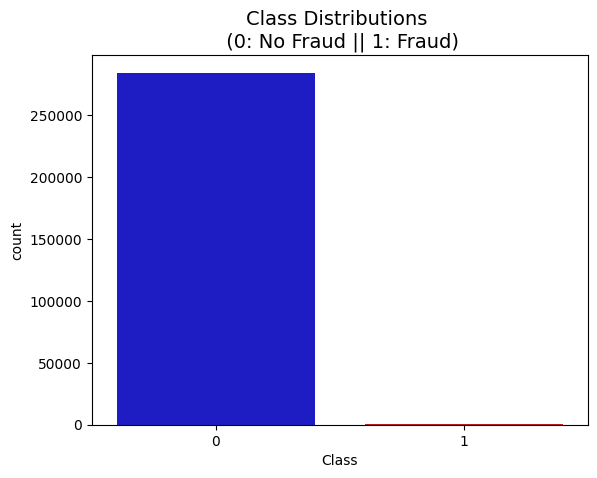

In [ ]:
# The classes are heavily IMBALANCED  and this might lead to overfitting
print('No Frauds', round(df['Class'].value_counts()[0]/len(df) * 100,2), '% of the dataset')
print('Frauds', round(df['Class'].value_counts()[1]/len(df) * 100,2), '% of the dataset')

colors = ["#0101DF", "#DF0101"]

sns.countplot(x='Class', data=df, palette=colors)
plt.title('Class Distributions \n (0: No Fraud || 1: Fraud)', fontsize=14)

**Distributions:** By seeing the distributions we can have an idea how skewed are these features, we can also see further distributions of the other features.

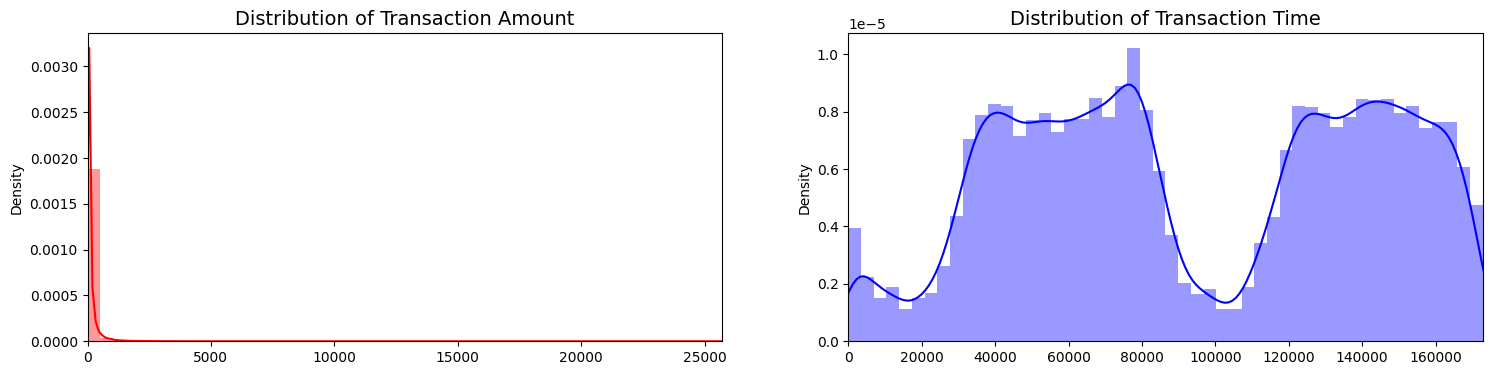

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(18,4))

amount_val = df['Amount'].values
time_val = df['Time'].values

sns.distplot(amount_val, ax=ax[0], color='r')
ax[0].set_title('Distribution of Transaction Amount', fontsize=14)
ax[0].set_xlim([min(amount_val), max(amount_val)])

sns.distplot(time_val, ax=ax[1], color='b')
ax[1].set_title('Distribution of Transaction Time', fontsize=14)
ax[1].set_xlim([min(time_val), max(time_val)])



plt.show()

<h2> Data Scaling and Balanced Sampling (Preprocessing)</h2>
<a id="preprocessing"></a>



<h3> Feature Scaling </h3>

The <b>Time</b> and <b>Amount</b> columns are scaled separately before training because they were not included in the original feature transformation process.

<h3> Balanced Sampling </h3>

To improve fraud detection, a balanced subset of the dataset is created. This subset contains an equal number of fraudulent and non-fraudulent transactions.

In [ ]:
# Since most of our data has already been scaled we should scale the columns that are left to scale (Amount and Time)
from sklearn.preprocessing import StandardScaler, RobustScaler

# RobustScaler is less prone to outliers.

std_scaler = StandardScaler()
rob_scaler = RobustScaler()

df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))

df.drop(['Time','Amount'], axis=1, inplace=True)

scaled_amount = df['scaled_amount']
scaled_time = df['scaled_time']

df.drop(['scaled_amount', 'scaled_time'], axis=1, inplace=True)
df.insert(0, 'scaled_amount', scaled_amount)
df.insert(1, 'scaled_time', scaled_time)

# Amount and Time are Scaled!

df.head()

,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,1.783274,-0.994983,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.269825,-0.994983,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,4.983721,-0.994972,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,1.418291,-0.994972,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,0.670579,-0.994960,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


<h3> Splitting the Dataset </h3>
<a id="splitting"></a>

Before applying <b>Undersampling</b> or <b>Oversampling</b>, the original dataset should first be divided into training and testing sets.

The sampling techniques are  applied only to the <b> training data </b> so that the model can learn fraud patterns more clearly. However, the testing data should remain in its original imbalanced form to check how well the model performs on actual transaction data.




In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit

# Safety check: keep the same logic, but remove incomplete rows if the uploaded CSV has any.
df = df.dropna().reset_index(drop=True)
df['Class'] = df['Class'].astype(int)

# print('No Frauds', round(df['Class'].value_counts()[0]/len(df) * 100,2), '% of the dataset')
# print('Frauds', round(df['Class'].value_counts()[1]/len(df) * 100,2), '% of the dataset')

X = df.drop('Class', axis=1)
y = df['Class']

sss = StratifiedKFold(n_splits=5, random_state=None, shuffle=False)

for train_index, test_index in sss.split(X, y):
    print("Train:", train_index, "Test:", test_index)
    original_Xtrain, original_Xtest = X.iloc[train_index], X.iloc[test_index]
    original_ytrain, original_ytest = y.iloc[train_index], y.iloc[test_index]

# Turn into an array
original_Xtrain = original_Xtrain.values
original_Xtest = original_Xtest.values
original_ytrain = original_ytrain.values
original_ytest = original_ytest.values

# See if both the train and test label distribution are similarly distributed
train_unique_label, train_counts_label = np.unique(original_ytrain, return_counts=True)
test_unique_label, test_counts_label = np.unique(original_ytest, return_counts=True)
print('-' * 100)

print('Label Distributions: \n')
print(train_counts_label/ len(original_ytrain))
print(test_counts_label/ len(original_ytest))

Train: [ 30473  30496  31002 ... 284804 284805 284806] Test: [    0     1     2 ... 57017 57018 57019]
Train: [     0      1      2 ... 284804 284805 284806] Test: [ 30473  30496  31002 ... 113964 113965 113966]
Train: [     0      1      2 ... 284804 284805 284806] Test: [ 81609  82400  83053 ... 170946 170947 170948]
Train: [     0      1      2 ... 284804 284805 284806] Test: [150654 150660 150661 ... 227866 227867 227868]
Train: [     0      1      2 ... 227866 227867 227868] Test: [212516 212644 213092 ... 284804 284805 284806]
----------------------------------------------------------------------------------------------------
Label Distributions: 

[0.99827076 0.00172924]
[0.99827952 0.00172048]


<h2> Under-Sampling </h2>
<a id="undersampling"></a>

In this section, we apply <b> Under-Sampling</b> to balance the dataset.
<ul>
<li> Random Under-Sampling can reduce class imbalance and improve fraud pattern learning. </li>

<li> However, it removes many non-fraud records from the dataset. </li>

<li> This may lead to <b>information loss</b>, because only a small portion of the original non-fraud transactions is used. </li>
</ul>

Distribution of the Classes in the subsample dataset
Class
0    0.5
1    0.5
Name: count, dtype: float64


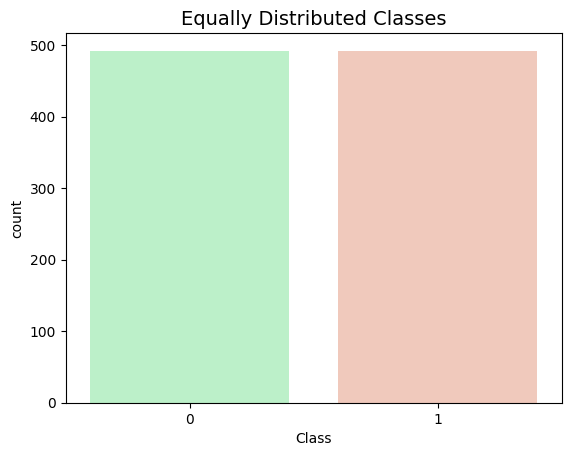

In [ ]:

# Lets shuffle the data before creating the subsamples

df = df.sample(frac=1)

# amount of fraud classes 492 rows.
fraud_df = df.loc[df['Class'] == 1]
non_fraud_df = df.loc[df['Class'] == 0][:492]

normal_distributed_df = pd.concat([fraud_df, non_fraud_df])

# Shuffle dataframe rows
new_df = normal_distributed_df.sample(frac=1, random_state=42)

print('Distribution of the Classes in the subsample dataset')
print(new_df['Class'].value_counts()/len(new_df))


sns.countplot(x='Class', data=new_df, palette=colors)
plt.title('Equally Distributed Classes', fontsize=14)
plt.show()

<h3> Feature Correlation Analysis </h3>

Correlation analysis helps us understand the relationship between dataset features and fraud transactions.Using correlation matrix, we can identify which variables have a strong influence on predicting fraudulent activities.

To obtain meaningful results, the correlation matrix should be generated using the <b>balanced sub-sample dataset</b> rather than the original imbalanced dataset.

<h3> Analysis Summary: </h3>

<ul>
<li><b>Negative Correlation:</b> Features such as <b>V10, V12, V14, and V17</b> show strong negative correlation with fraud transactions. Lower values in these features are more commonly associated with fraudulent behavior. </li>

<li><b>Positive Correlation:</b> Features including <b>V2, V4, V11, and V19</b> display positive correlation with fraud transactions. Higher values in these variables increase the likelihood of a transaction being fraudulent. </li>

<li><b>Feature Distribution:</b> Boxplots are used to compare the distribution of important features between fraud and non-fraud transactions. This helps visualize outliers and class differences more clearly. </li>
</ul>


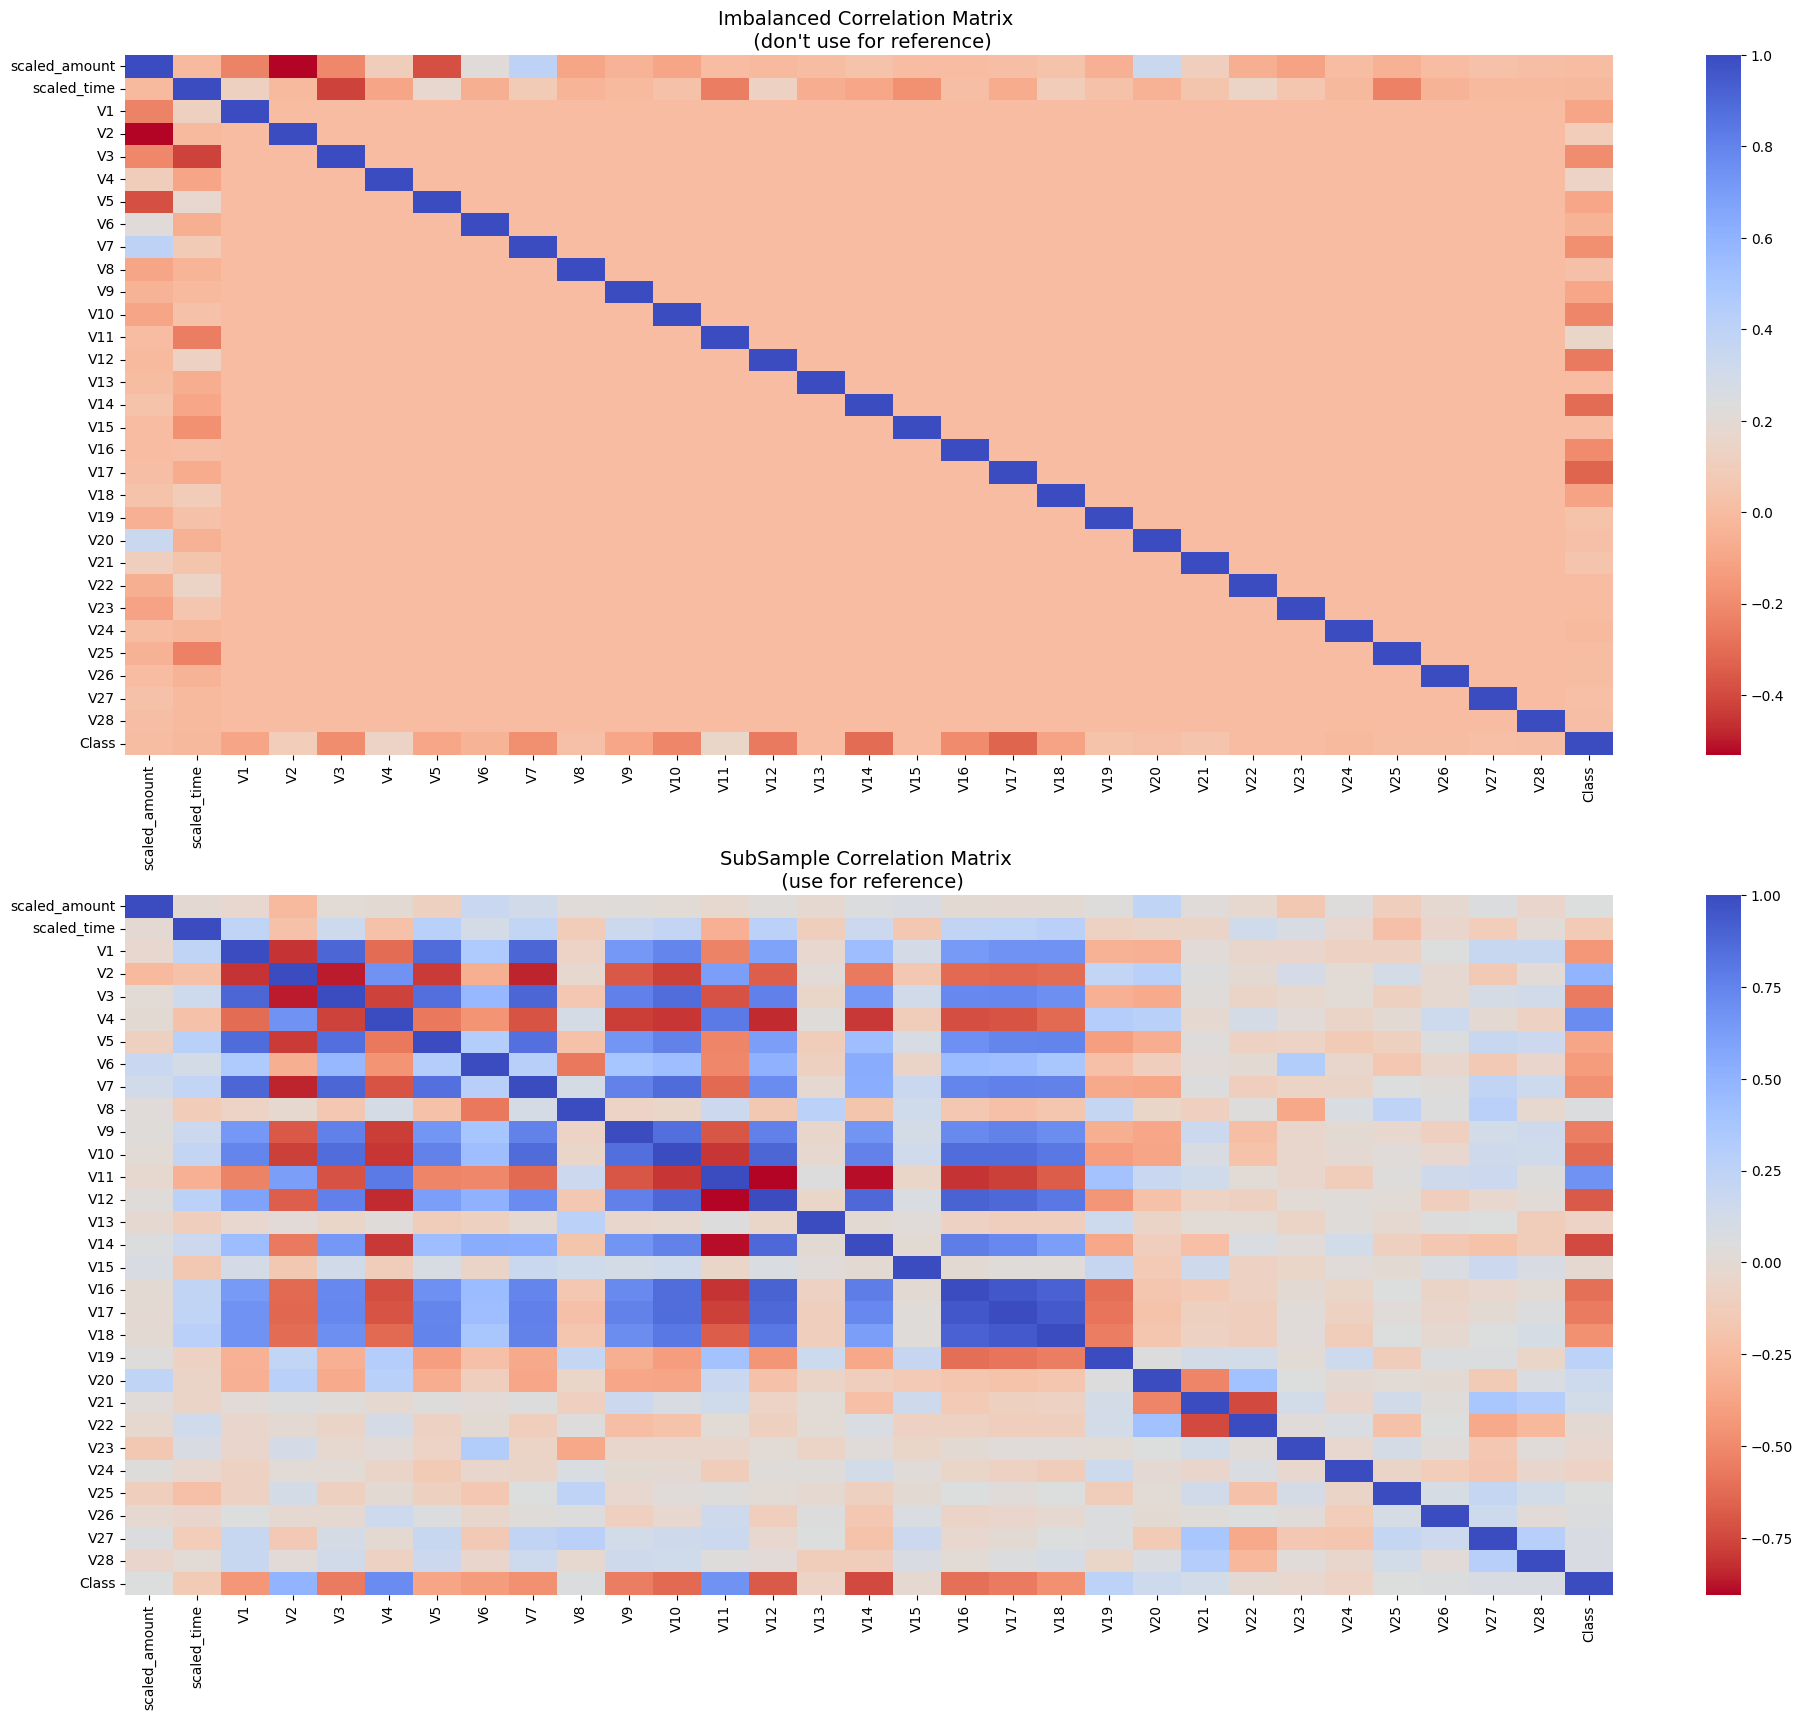

In [ ]:
# Make sure we use the subsample in our correlation
f, (ax1, ax2) = plt.subplots(2, 1, figsize=(24,20))

# Entire DataFrame
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm_r', annot_kws={'size':20}, ax=ax1)
ax1.set_title("Imbalanced Correlation Matrix \n (don't use for reference)", fontsize=14)


sub_sample_corr = new_df.corr()
sns.heatmap(sub_sample_corr, cmap='coolwarm_r', annot_kws={'size':20}, ax=ax2)
ax2.set_title('SubSample Correlation Matrix \n (use for reference)', fontsize=14)
plt.show()

# Negative Correlations with our Class (The lower our feature value the more likely it will be a fraud transaction)

In [ ]:
f, axes = plt.subplots(ncols=4, figsize=(20,4))

# Negative Correlations with our Class (The lower our feature value the more likely it will be a fraud transaction)
sns.boxplot(x="Class", y="V17", data=new_df, palette=colors, ax=axes[0])
axes[0].set_title('V17 vs Class Negative Correlation')

sns.boxplot(x="Class", y="V14", data=new_df, palette=colors, ax=axes[1])
axes[1].set_title('V14 vs Class Negative Correlation')


sns.boxplot(x="Class", y="V12", data=new_df, palette=colors, ax=axes[2])
axes[2].set_title('V12 vs Class Negative Correlation')


sns.boxplot(x="Class", y="V10", data=new_df, palette=colors, ax=axes[3])
axes[3].set_title('V10 vs Class Negative Correlation')

plt.show()

NameError: name 'plt' is not defined

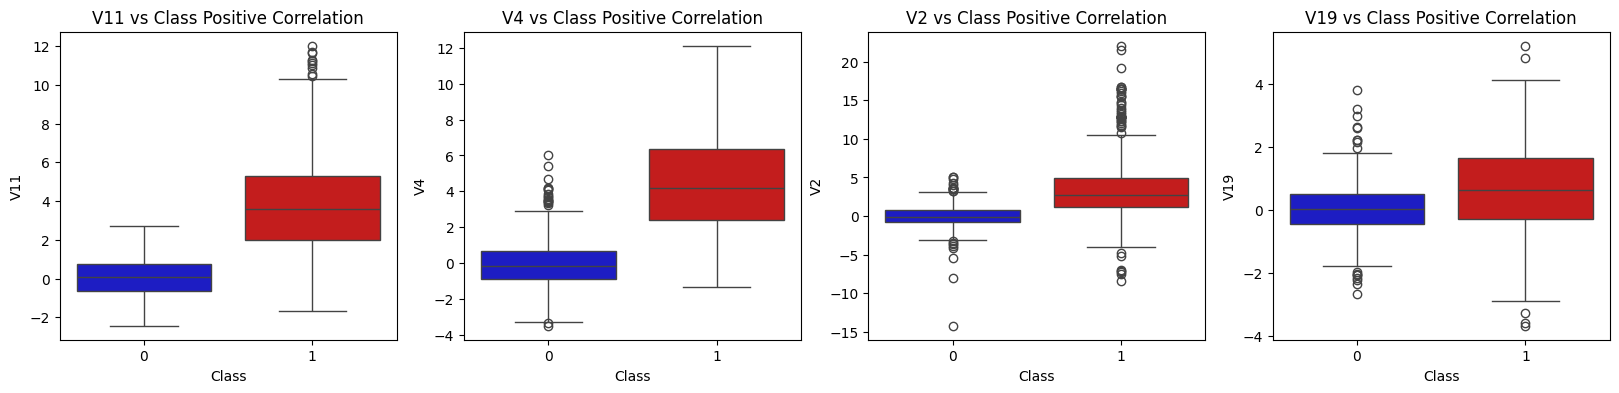

In [ ]:
f, axes = plt.subplots(ncols=4, figsize=(20,4))

# Positive correlations (The higher the feature the probability increases that it will be a fraud transaction)
sns.boxplot(x="Class", y="V11", data=new_df, palette=colors, ax=axes[0])
axes[0].set_title('V11 vs Class Positive Correlation')

sns.boxplot(x="Class", y="V4", data=new_df, palette=colors, ax=axes[1])
axes[1].set_title('V4 vs Class Positive Correlation')


sns.boxplot(x="Class", y="V2", data=new_df, palette=colors, ax=axes[2])
axes[2].set_title('V2 vs Class Positive Correlation')


sns.boxplot(x="Class", y="V19", data=new_df, palette=colors, ax=axes[3])
axes[3].set_title('V19 vs Class Positive Correlation')

plt.show()

<h2>Anomaly Outlier Detection and Removal </h2>
<a id="outlier"></a>


<h3> Interquartile Range (IQR) Method </h3>

<ul>
<li> <b>Interquartile Range (IQR):</b> The IQR is calculated by subtracting the 25th percentile (Q1) from the 75th percentile (Q3). This method helps identify unusually high or low values in the dataset. </li>

<li> <b>Threshold Calculation:</b> A threshold value is created using the IQR. Any data points falling below or above this threshold are considered potential outliers. </li>

<li> <b>Boxplot Visualization:</b> Boxplots help visualize feature distributions and make it easier to identify extreme outlier points. </li>
</ul>

<h3> Outlier Removal Strategy </h3>

The threshold is controlled using a multiplication factor applied to the IQR value.

<ul>
<li> A lower threshold removes more outliers. </li>

<li> A higher threshold removes fewer outliers. </li>


</ul>

Removing too many records may lead to information loss and reduce the model’s ability to generalize properly.

<h3> Summary: </h3>

<ul>
<li> Important features are analyzed individually to study their distribution patterns. </li>

<li> Features such as <b>V10</b>, <b>V12</b>, and <b>V14</b> are examined carefully because of their strong relationship with fraud transactions. </li>

<li> Upper and lower thresholds are calculated using the IQR technique. </li>

<li> Transactions exceeding the defined threshold are removed from the dataset. </li>

<li> Boxplots are used again after preprocessing to confirm the reduction of extreme outliers. </li>

<li> Controlled outlier removal can improve model performance and reduce noise in the dataset. </li>
</ul>

<h3> Important Note: </h3>

<ul>
<li> Excessive outlier removal may result in underfitting due to information loss. </li>

<li> A balanced approach is necessary to maintain both data quality and model accuracy. </li>
</ul>

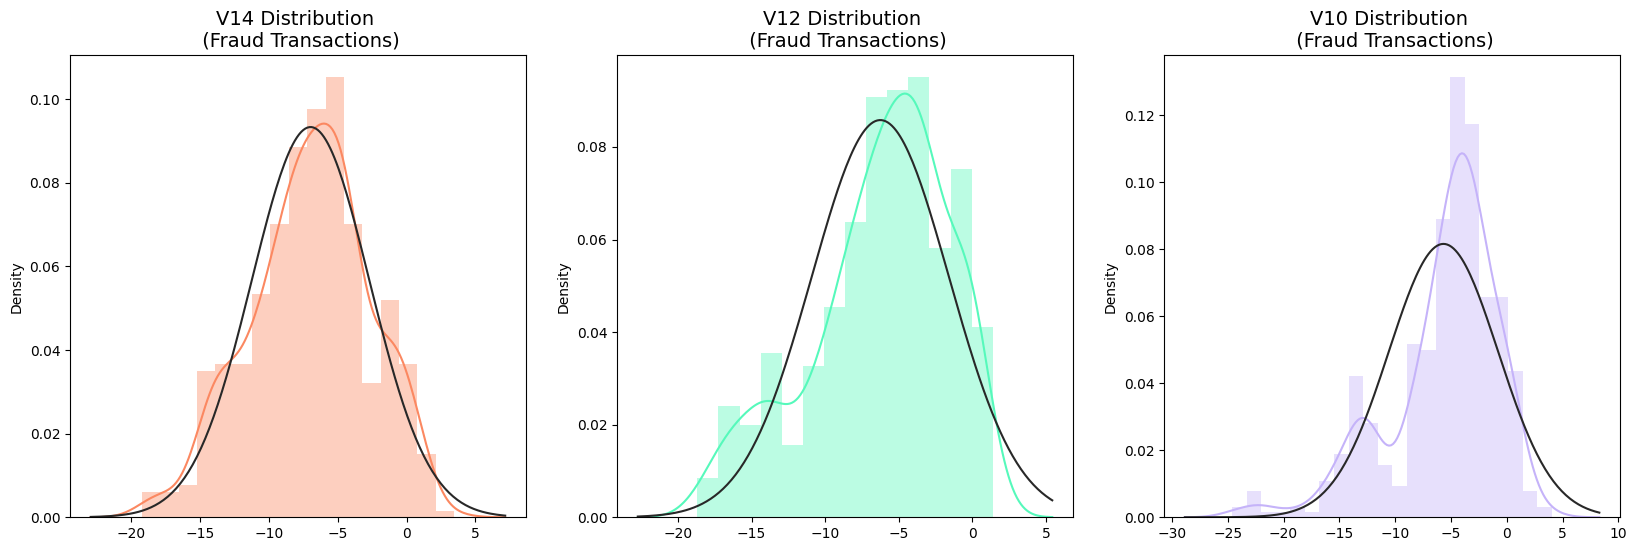

In [ ]:
from scipy.stats import norm

f, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(20, 6))

v14_fraud_dist = new_df['V14'].loc[new_df['Class'] == 1].values
sns.distplot(v14_fraud_dist,ax=ax1, fit=norm, color='#FB8861')
ax1.set_title('V14 Distribution \n (Fraud Transactions)', fontsize=14)

v12_fraud_dist = new_df['V12'].loc[new_df['Class'] == 1].values
sns.distplot(v12_fraud_dist,ax=ax2, fit=norm, color='#56F9BB')
ax2.set_title('V12 Distribution \n (Fraud Transactions)', fontsize=14)


v10_fraud_dist = new_df['V10'].loc[new_df['Class'] == 1].values
sns.distplot(v10_fraud_dist,ax=ax3, fit=norm, color='#C5B3F9')
ax3.set_title('V10 Distribution \n (Fraud Transactions)', fontsize=14)

plt.show()

In [ ]:
# # -----> V14 Removing Outliers (Highest Negative Correlated with Labels)
v14_fraud = new_df['V14'].loc[new_df['Class'] == 1].values
q25, q75 = np.percentile(v14_fraud, 25), np.percentile(v14_fraud, 75)
print('Quartile 25: {} | Quartile 75: {}'.format(q25, q75))
v14_iqr = q75 - q25
print('iqr: {}'.format(v14_iqr))

v14_cut_off = v14_iqr * 1.5
v14_lower, v14_upper = q25 - v14_cut_off, q75 + v14_cut_off
print('Cut Off: {}'.format(v14_cut_off))
print('V14 Lower: {}'.format(v14_lower))
print('V14 Upper: {}'.format(v14_upper))

outliers = [x for x in v14_fraud if x < v14_lower or x > v14_upper]
print('Feature V14 Outliers for Fraud Cases: {}'.format(len(outliers)))
print('V10 outliers:{}'.format(outliers))

new_df = new_df.drop(new_df[(new_df['V14'] > v14_upper) | (new_df['V14'] < v14_lower)].index)
print('----' * 44)

# -----> V12 removing outliers from fraud transactions
v12_fraud = new_df['V12'].loc[new_df['Class'] == 1].values
q25, q75 = np.percentile(v12_fraud, 25), np.percentile(v12_fraud, 75)
v12_iqr = q75 - q25

v12_cut_off = v12_iqr * 1.5
v12_lower, v12_upper = q25 - v12_cut_off, q75 + v12_cut_off
print('V12 Lower: {}'.format(v12_lower))
print('V12 Upper: {}'.format(v12_upper))
outliers = [x for x in v12_fraud if x < v12_lower or x > v12_upper]
print('V12 outliers: {}'.format(outliers))
print('Feature V12 Outliers for Fraud Cases: {}'.format(len(outliers)))
new_df = new_df.drop(new_df[(new_df['V12'] > v12_upper) | (new_df['V12'] < v12_lower)].index)
print('Number of Instances after outliers removal: {}'.format(len(new_df)))
print('----' * 44)


# Removing outliers V10 Feature
v10_fraud = new_df['V10'].loc[new_df['Class'] == 1].values
q25, q75 = np.percentile(v10_fraud, 25), np.percentile(v10_fraud, 75)
v10_iqr = q75 - q25

v10_cut_off = v10_iqr * 1.5
v10_lower, v10_upper = q25 - v10_cut_off, q75 + v10_cut_off
print('V10 Lower: {}'.format(v10_lower))
print('V10 Upper: {}'.format(v10_upper))
outliers = [x for x in v10_fraud if x < v10_lower or x > v10_upper]
print('V10 outliers: {}'.format(outliers))
print('Feature V10 Outliers for Fraud Cases: {}'.format(len(outliers)))
new_df = new_df.drop(new_df[(new_df['V10'] > v10_upper) | (new_df['V10'] < v10_lower)].index)
print('Number of Instances after outliers removal: {}'.format(len(new_df)))

Quartile 25: -9.692722964972386 | Quartile 75: -4.282820849486865
iqr: 5.409902115485521
Cut Off: 8.114853173228282
V14 Lower: -17.807576138200666
V14 Upper: 3.8320323237414167
Feature V14 Outliers for Fraud Cases: 4
V10 outliers:[np.float64(-18.0499976898594), np.float64(-19.2143254902614), np.float64(-18.4937733551053), np.float64(-18.8220867423816)]
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
V12 Lower: -17.3430371579634
V12 Upper: 5.776973384895937
V12 outliers: [np.float64(-18.4311310279993), np.float64(-18.0475965708216), np.float64(-18.5536970096458), np.float64(-18.6837146333443)]
Feature V12 Outliers for Fraud Cases: 4
Number of Instances after outliers removal: 974
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
V10 Lo

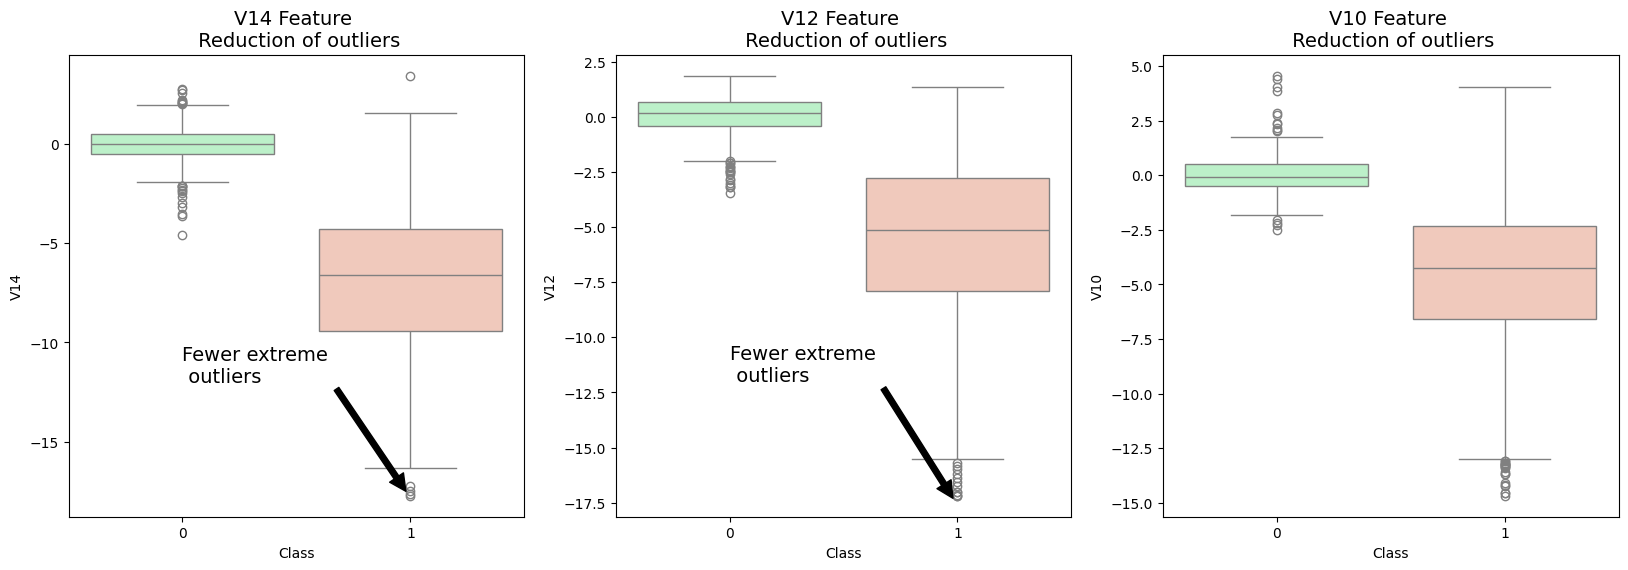

In [ ]:
f,(ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20,6))

colors = ['#B3F9C5', '#f9c5b3']
# Boxplots with outliers removed
# Feature V14
sns.boxplot(x="Class", y="V14", data=new_df,ax=ax1, palette=colors)
ax1.set_title("V14 Feature \n Reduction of outliers", fontsize=14)
ax1.annotate('Fewer extreme \n outliers', xy=(0.98, -17.5), xytext=(0, -12),
            arrowprops=dict(facecolor='black'),
            fontsize=14)

# Feature 12
sns.boxplot(x="Class", y="V12", data=new_df, ax=ax2, palette=colors)
ax2.set_title("V12 Feature \n Reduction of outliers", fontsize=14)
ax2.annotate('Fewer extreme \n outliers', xy=(0.98, -17.3), xytext=(0, -12),
            arrowprops=dict(facecolor='black'),
            fontsize=14)

# Feature V10
sns.boxplot(x="Class", y="V10", data=new_df, ax=ax3, palette=colors)
ax3.set_title("V10 Feature \n Reduction of outliers", fontsize=14)
ax3.annotate('Fewer extreme \n outliers', xy=(0.95, -16.5), xytext=(0, -12),
            arrowprops=dict(facecolor='black'),
            fontsize=14)


plt.show()

<h2> Dimensionality Reduction and Clustering </h2>
<a id="clustering"></a>

In this section, dimensionality reduction techniques are used to visualize the dataset and understand how fraud and non-fraud transactions are grouped. Since the dataset contains many transformed features, visualization methods help simplify the data into lower dimensions while preserving important patterns.

<h3> Understanding t-SNE </h3>

t-SNE (t-Distributed Stochastic Neighbor Embedding) is a dimensionality reduction technique mainly used for data visualization and clustering analysis. It helps represent high-dimensional data in two-dimensional space while preserving similarities between observations.

t-SNE is useful for identifying hidden patterns and observing whether fraud transactions form separate clusters from normal transactions.

<h3> Summary: </h3>

<ul>
<li> The t-SNE algorithm successfully groups fraud and non-fraud transactions into distinct clusters. </li>

<li> Even with a smaller balanced dataset, the clustering results remain consistent after data shuffling. </li>

<li> Fraudulent transactions show visible separation from legitimate transactions in lower-dimensional space. </li>

<li> The clustering results indicate that Machine Learning models can effectively learn patterns related to fraud detection. </li>

<li> Dimensionality reduction also improves data visualization and helps understand feature relationships more clearly. </li>
</ul>

In [ ]:
# New_df is from the random undersample data (fewer instances)
X = new_df.drop('Class', axis=1)
y = new_df['Class']


# T-SNE Implementation
t0 = time.time()
X_reduced_tsne = TSNE(n_components=2, random_state=42).fit_transform(X.values)
t1 = time.time()
print("T-SNE took {:.2} s".format(t1 - t0))

# PCA Implementation
t0 = time.time()
X_reduced_pca = PCA(n_components=2, random_state=42).fit_transform(X.values)
t1 = time.time()
print("PCA took {:.2} s".format(t1 - t0))

# TruncatedSVD
t0 = time.time()
X_reduced_svd = TruncatedSVD(n_components=2, algorithm='randomized', random_state=42).fit_transform(X.values)
t1 = time.time()
print("Truncated SVD took {:.2} s".format(t1 - t0))

T-SNE took 1.1e+01 s
PCA took 0.011 s
Truncated SVD took 0.029 s


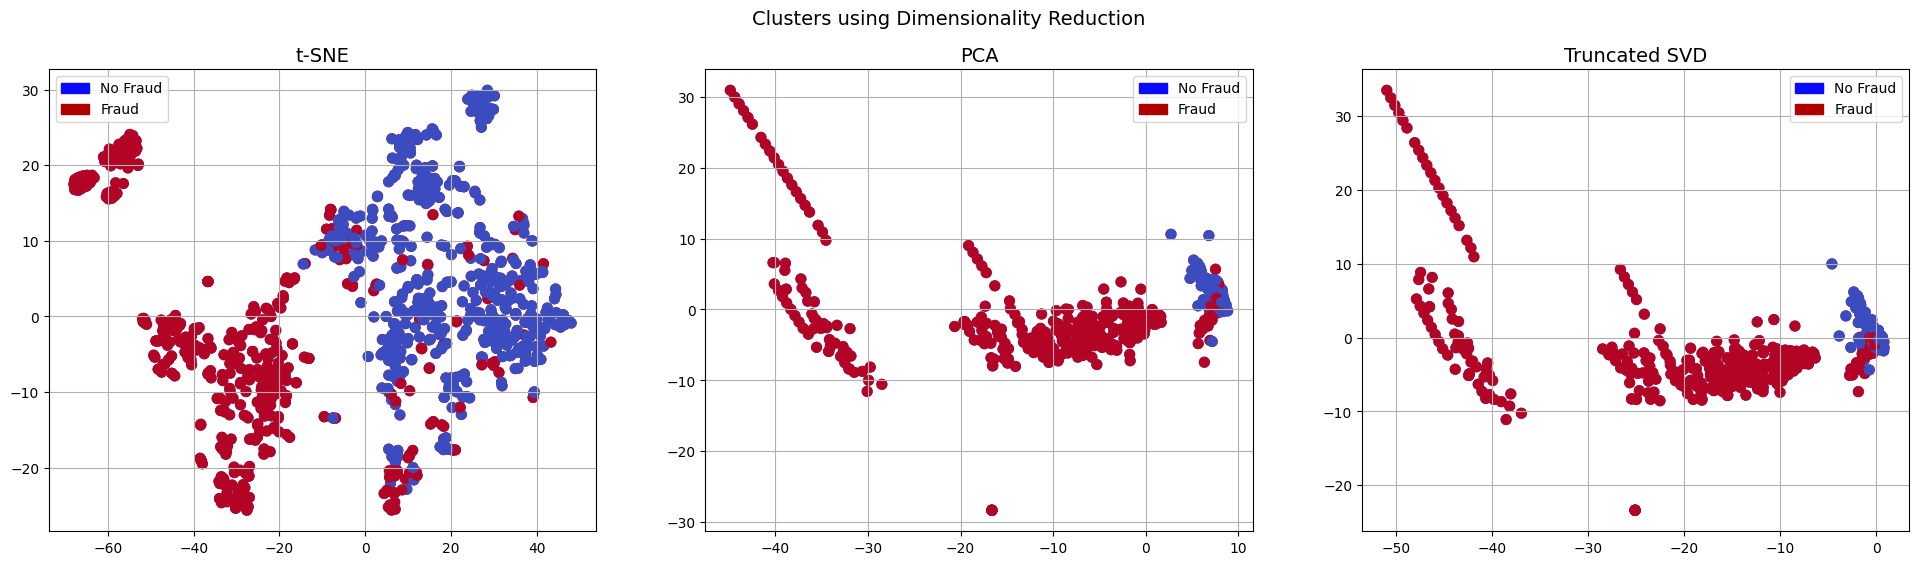

In [ ]:
f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24,6))
# labels = ['No Fraud', 'Fraud']
f.suptitle('Clusters using Dimensionality Reduction', fontsize=14)


blue_patch = mpatches.Patch(color='#0A0AFF', label='No Fraud')
red_patch = mpatches.Patch(color='#AF0000', label='Fraud')


# t-SNE scatter plot
ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y == 0), cmap='coolwarm', label='No Fraud', linewidths=2)
ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y == 1), cmap='coolwarm', label='Fraud', linewidths=2)
ax1.set_title('t-SNE', fontsize=14)

ax1.grid(True)

ax1.legend(handles=[blue_patch, red_patch])


# PCA scatter plot
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=(y == 0), cmap='coolwarm', label='No Fraud', linewidths=2)
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=(y == 1), cmap='coolwarm', label='Fraud', linewidths=2)
ax2.set_title('PCA', fontsize=14)

ax2.grid(True)

ax2.legend(handles=[blue_patch, red_patch])

# TruncatedSVD scatter plot
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(y == 0), cmap='coolwarm', label='No Fraud', linewidths=2)
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(y == 1), cmap='coolwarm', label='Fraud', linewidths=2)
ax3.set_title('Truncated SVD', fontsize=14)

ax3.grid(True)

ax3.legend(handles=[blue_patch, red_patch])

plt.show()

<h2> Classification Models (Undersampling) </h2>
<a id="classifiers"></a>


<h3> Models Used </h3>

<ul>
<li> Logistic Regression </li>

<li> Support Vector Machine (SVM) </li>

<li> Decision Tree Classifier </li>

<li> Random Forest Classifier </li>
</ul>

<h3> Model Evaluation </h3>

The classifiers are evaluated using different performance metrics to measure how effectively they identify fraud transactions.

<h3> Summary: </h3>

<ul>
<li> <b>Logistic Regression</b> performs better compared to the other classification models in most evaluation cases. </li>

<li> <b>GridSearchCV</b> is applied to identify the best hyperparameters for each classifier and improve predictive performance. </li>

<li> Logistic Regression achieves the strongest <b>ROC-AUC score</b>, showing better separation between fraud and non-fraud transactions. </li>

<li> The balanced dataset improves the ability of classifiers to detect fraud patterns more effectively. </li>
</ul>

<h3> Learning Curve Analysis </h3>

<ul>
<li> A large difference between training accuracy and cross-validation accuracy may indicate <b>overfitting</b>. </li>

<li> Low performance on both training and validation data may suggest <b>underfitting</b>. </li>

<li> Logistic Regression shows stable performance across both training and validation datasets. </li>

<li> Consistent learning curves indicate better generalization capability of the model. </li>
</ul>

In [ ]:
# Undersampling before cross validating (prone to overfit)
X = new_df.drop('Class', axis=1)
y = new_df['Class']

In [ ]:
# Our data is already scaled we should split our training and test sets
from sklearn.model_selection import train_test_split

# This is explicitly used for undersampling.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Turn the values into an array for feeding the classification algorithms.
X_train = X_train.values
X_test = X_test.values
y_train = y_train.values
y_test = y_test.values

In [ ]:
# Let's implement simple classifiers

classifiers = {
    "LogisiticRegression": LogisticRegression(),
    "KNearest": KNeighborsClassifier(),
    "Support Vector Classifier": SVC(),
    "DecisionTreeClassifier": DecisionTreeClassifier()
}

In [ ]:
# Wow our scores are getting even high scores even when applying cross validation.
from sklearn.model_selection import cross_val_score


for key, classifier in classifiers.items():
    classifier.fit(X_train, y_train)
    training_score = cross_val_score(classifier, X_train, y_train, cv=5)
    print("Classifiers: ", classifier.__class__.__name__, "Has a training score of", round(training_score.mean(), 2) * 100, "% accuracy score")

Classifiers:  LogisticRegression Has a training score of 94.0 % accuracy score
Classifiers:  KNeighborsClassifier Has a training score of 93.0 % accuracy score
Classifiers:  SVC Has a training score of 93.0 % accuracy score
Classifiers:  DecisionTreeClassifier Has a training score of 89.0 % accuracy score


In [ ]:
# Use GridSearchCV to find the best parameters.
from sklearn.model_selection import GridSearchCV


# Logistic Regression
log_reg_params = {"penalty": ['l1', 'l2'], 'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}



grid_log_reg = GridSearchCV(LogisticRegression(), log_reg_params)
grid_log_reg.fit(X_train, y_train)
# We automatically get the logistic regression with the best parameters.
log_reg = grid_log_reg.best_estimator_

knears_params = {"n_neighbors": list(range(2,5,1)), 'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']}

grid_knears = GridSearchCV(KNeighborsClassifier(), knears_params)
grid_knears.fit(X_train, y_train)
# KNears best estimator
knears_neighbors = grid_knears.best_estimator_

# Support Vector Classifier
svc_params = {'C': [0.5, 0.7, 0.9, 1], 'kernel': ['rbf', 'poly', 'sigmoid', 'linear']}
grid_svc = GridSearchCV(SVC(), svc_params)
grid_svc.fit(X_train, y_train)

# SVC best estimator
svc = grid_svc.best_estimator_

# DecisionTree Classifier
tree_params = {"criterion": ["gini", "entropy"], "max_depth": list(range(2,4,1)),
              "min_samples_leaf": list(range(5,7,1))}
grid_tree = GridSearchCV(DecisionTreeClassifier(), tree_params)
grid_tree.fit(X_train, y_train)

# tree best estimator
tree_clf = grid_tree.best_estimator_

In [ ]:
# Overfitting Case

log_reg_score = cross_val_score(log_reg, X_train, y_train, cv=5)
print('Logistic Regression Cross Validation Score: ', round(log_reg_score.mean() * 100, 2).astype(str) + '%')


knears_score = cross_val_score(knears_neighbors, X_train, y_train, cv=5)
print('Knears Neighbors Cross Validation Score', round(knears_score.mean() * 100, 2).astype(str) + '%')

svc_score = cross_val_score(svc, X_train, y_train, cv=5)
print('Support Vector Classifier Cross Validation Score', round(svc_score.mean() * 100, 2).astype(str) + '%')

tree_score = cross_val_score(tree_clf, X_train, y_train, cv=5)
print('DecisionTree Classifier Cross Validation Score', round(tree_score.mean() * 100, 2).astype(str) + '%')

Logistic Regression Cross Validation Score:  94.84%
Knears Neighbors Cross Validation Score 93.65%
Support Vector Classifier Cross Validation Score 93.52%
DecisionTree Classifier Cross Validation Score 91.54%


In [ ]:
# We will undersample during cross validating
undersample_X = df.drop('Class', axis=1)
undersample_y = df['Class']

for train_index, test_index in sss.split(undersample_X, undersample_y):
    print("Train:", train_index, "Test:", test_index)
    undersample_Xtrain, undersample_Xtest = undersample_X.iloc[train_index], undersample_X.iloc[test_index]
    undersample_ytrain, undersample_ytest = undersample_y.iloc[train_index], undersample_y.iloc[test_index]

undersample_Xtrain = undersample_Xtrain.values
undersample_Xtest = undersample_Xtest.values
undersample_ytrain = undersample_ytrain.values
undersample_ytest = undersample_ytest.values

undersample_accuracy = []
undersample_precision = []
undersample_recall = []
undersample_f1 = []
undersample_auc = []

# Implementing NearMiss Technique
# Distribution of NearMiss (Just to see how it distributes the labels we won't use these variables)
X_nearmiss, y_nearmiss = NearMiss().fit_resample(undersample_X.values, undersample_y.values)
print('NearMiss Label Distribution: {}'.format(Counter(y_nearmiss)))
# Cross Validating the right way

for train, test in sss.split(undersample_Xtrain, undersample_ytrain):
    undersample_pipeline = imbalanced_make_pipeline(NearMiss(sampling_strategy='majority'), log_reg) # SMOTE happens during Cross Validation not before..
    undersample_model = undersample_pipeline.fit(undersample_Xtrain[train], undersample_ytrain[train])
    undersample_prediction = undersample_model.predict(undersample_Xtrain[test])

    undersample_accuracy.append(undersample_pipeline.score(original_Xtrain[test], original_ytrain[test]))
    undersample_precision.append(precision_score(original_ytrain[test], undersample_prediction))
    undersample_recall.append(recall_score(original_ytrain[test], undersample_prediction))
    undersample_f1.append(f1_score(original_ytrain[test], undersample_prediction))
    undersample_auc.append(roc_auc_score(original_ytrain[test], undersample_prediction))

Train: [ 56621  56910  56964 ... 284804 284805 284806] Test: [    0     1     2 ... 56961 56962 56963]
Train: [     0      1      2 ... 284804 284805 284806] Test: [ 56621  56910  56964 ... 115735 116292 116666]
Train: [     0      1      2 ... 284804 284805 284806] Test: [113918 113919 113920 ... 170902 170903 170904]
Train: [     0      1      2 ... 284804 284805 284806] Test: [161131 161537 162353 ... 229379 229442 229849]
Train: [     0      1      2 ... 229379 229442 229849] Test: [227842 227843 227844 ... 284804 284805 284806]
NearMiss Label Distribution: Counter({np.int64(0): 492, np.int64(1): 492})


In [ ]:
# Let's Plot LogisticRegression Learning Curve
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator1, estimator2, estimator3, estimator4, X, y, ylim=None, cv=None,
                        n_jobs=1, train_sizes=np.linspace(.1, 1.0, 5)):
    f, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize=(20,14), sharey=True)
    if ylim is not None:
        plt.ylim(*ylim)
    # First Estimator
    train_sizes, train_scores, test_scores = learning_curve(
        estimator1, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    ax1.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="#ff9124")
    ax1.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="#2492ff")
    ax1.plot(train_sizes, train_scores_mean, 'o-', color="#ff9124",
             label="Training score")
    ax1.plot(train_sizes, test_scores_mean, 'o-', color="#2492ff",
             label="Cross-validation score")
    ax1.set_title("Logistic Regression Learning Curve", fontsize=14)
    ax1.set_xlabel('Training size (m)')
    ax1.set_ylabel('Score')
    ax1.grid(True)
    ax1.legend(loc="best")

    # Second Estimator
    train_sizes, train_scores, test_scores = learning_curve(
        estimator2, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    ax2.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="#ff9124")
    ax2.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="#2492ff")
    ax2.plot(train_sizes, train_scores_mean, 'o-', color="#ff9124",
             label="Training score")
    ax2.plot(train_sizes, test_scores_mean, 'o-', color="#2492ff",
             label="Cross-validation score")
    ax2.set_title("Knears Neighbors Learning Curve", fontsize=14)
    ax2.set_xlabel('Training size (m)')
    ax2.set_ylabel('Score')
    ax2.grid(True)
    ax2.legend(loc="best")

    # Third Estimator
    train_sizes, train_scores, test_scores = learning_curve(
        estimator3, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    ax3.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="#ff9124")
    ax3.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="#2492ff")
    ax3.plot(train_sizes, train_scores_mean, 'o-', color="#ff9124",
             label="Training score")
    ax3.plot(train_sizes, test_scores_mean, 'o-', color="#2492ff",
             label="Cross-validation score")
    ax3.set_title("Support Vector Classifier \n Learning Curve", fontsize=14)
    ax3.set_xlabel('Training size (m)')
    ax3.set_ylabel('Score')
    ax3.grid(True)
    ax3.legend(loc="best")

    # Fourth Estimator
    train_sizes, train_scores, test_scores = learning_curve(
        estimator4, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    ax4.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="#ff9124")
    ax4.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="#2492ff")
    ax4.plot(train_sizes, train_scores_mean, 'o-', color="#ff9124",
             label="Training score")
    ax4.plot(train_sizes, test_scores_mean, 'o-', color="#2492ff",
             label="Cross-validation score")
    ax4.set_title("Decision Tree Classifier \n Learning Curve", fontsize=14)
    ax4.set_xlabel('Training size (m)')
    ax4.set_ylabel('Score')
    ax4.grid(True)
    ax4.legend(loc="best")
    return plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

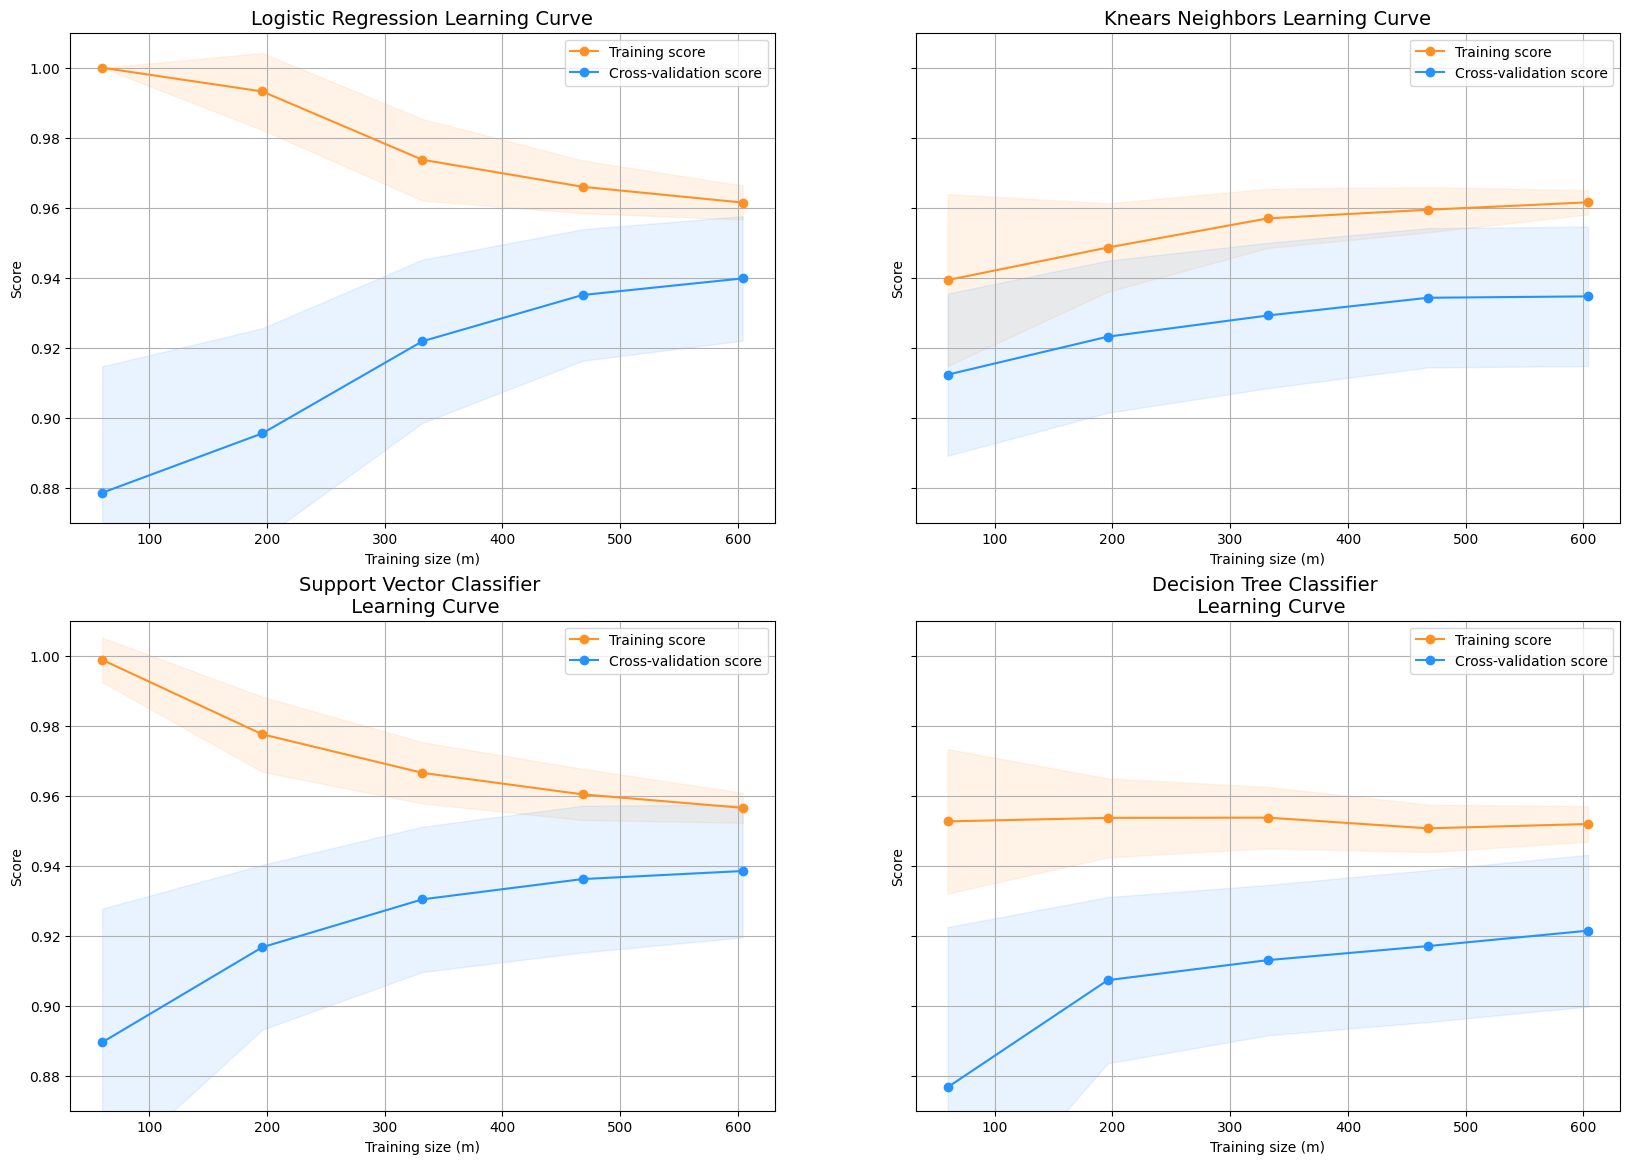

In [ ]:
cv = ShuffleSplit(n_splits=100, test_size=0.2, random_state=42)
plot_learning_curve(log_reg, knears_neighbors, svc, tree_clf, X_train, y_train, (0.87, 1.01), cv=cv, n_jobs=4)

In [ ]:
from sklearn.metrics import roc_curve
from sklearn.model_selection import cross_val_predict
# Create a DataFrame with all the scores and the classifiers names.

log_reg_pred = cross_val_predict(log_reg, X_train, y_train, cv=5,
                             method="decision_function")

knears_pred = cross_val_predict(knears_neighbors, X_train, y_train, cv=5)

svc_pred = cross_val_predict(svc, X_train, y_train, cv=5,
                             method="decision_function")

tree_pred = cross_val_predict(tree_clf, X_train, y_train, cv=5)

In [ ]:
from sklearn.metrics import roc_auc_score

print('Logistic Regression: ', roc_auc_score(y_train, log_reg_pred))
print('KNears Neighbors: ', roc_auc_score(y_train, knears_pred))
print('Support Vector Classifier: ', roc_auc_score(y_train, svc_pred))
print('Decision Tree Classifier: ', roc_auc_score(y_train, tree_pred))

Logistic Regression:  0.9710424167416742
KNears Neighbors:  0.9329151665166517
Support Vector Classifier:  0.9699946557155716
Decision Tree Classifier:  0.9164603960396039


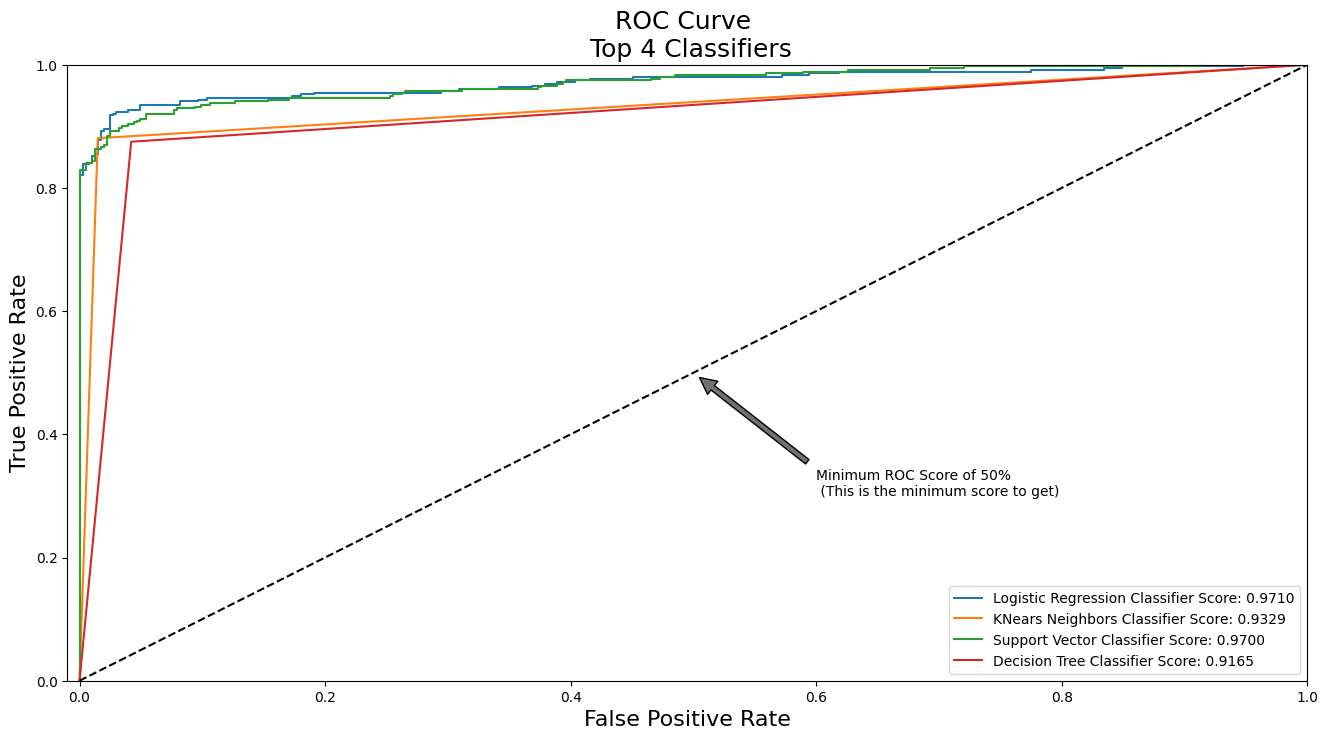

In [ ]:
log_fpr, log_tpr, log_thresold = roc_curve(y_train, log_reg_pred)
knear_fpr, knear_tpr, knear_threshold = roc_curve(y_train, knears_pred)
svc_fpr, svc_tpr, svc_threshold = roc_curve(y_train, svc_pred)
tree_fpr, tree_tpr, tree_threshold = roc_curve(y_train, tree_pred)


def graph_roc_curve_multiple(log_fpr, log_tpr, knear_fpr, knear_tpr, svc_fpr, svc_tpr, tree_fpr, tree_tpr):
    plt.figure(figsize=(16,8))
    plt.title('ROC Curve \n Top 4 Classifiers', fontsize=18)
    plt.plot(log_fpr, log_tpr, label='Logistic Regression Classifier Score: {:.4f}'.format(roc_auc_score(y_train, log_reg_pred)))
    plt.plot(knear_fpr, knear_tpr, label='KNears Neighbors Classifier Score: {:.4f}'.format(roc_auc_score(y_train, knears_pred)))
    plt.plot(svc_fpr, svc_tpr, label='Support Vector Classifier Score: {:.4f}'.format(roc_auc_score(y_train, svc_pred)))
    plt.plot(tree_fpr, tree_tpr, label='Decision Tree Classifier Score: {:.4f}'.format(roc_auc_score(y_train, tree_pred)))
    plt.plot([0, 1], [0, 1], 'k--')
    plt.axis([-0.01, 1, 0, 1])
    plt.xlabel('False Positive Rate', fontsize=16)
    plt.ylabel('True Positive Rate', fontsize=16)
    plt.annotate('Minimum ROC Score of 50% \n (This is the minimum score to get)', xy=(0.5, 0.5), xytext=(0.6, 0.3),
                arrowprops=dict(facecolor='#6E726D', shrink=0.05),
                )
    plt.legend()

graph_roc_curve_multiple(log_fpr, log_tpr, knear_fpr, knear_tpr, svc_fpr, svc_tpr, tree_fpr, tree_tpr)
plt.show()

<h2> Logistic Regression Analysis </h2>
<a id="logistic"></a>

In this section, we perform a more detailed analysis of the <b>Logistic Regression</b> classifier. Since Logistic Regression produced strong performance during model evaluation, it is important to understand how it predicts fraud transactions and how different evaluation metrics affect the model.

<h3> Important Terms </h3>

<ul>
<li><b>True Positive (TP):</b> Fraud transactions correctly identified as fraud. </li>

<li><b>False Positive (FP):</b> Legitimate transactions incorrectly classified as fraud. </li>

<li><b>True Negative (TN):</b> Legitimate transactions correctly identified as non-fraud. </li>

<li><b>False Negative (FN):</b> Fraud transactions incorrectly classified as legitimate. </li>

<li><b>Precision:</b> Measures how accurately the model predicts fraud transactions. </li>

<li><b>Recall:</b> Measures how many fraud transactions are successfully detected by the model. </li>

<li><b>Precision-Recall Balance:</b> Increasing precision may reduce recall, while increasing recall may reduce precision. Finding the right balance is important for fraud detection systems. </li>
</ul>

<h3> Precision and Recall Tradeoff </h3>

In fraud detection, achieving high precision means the model is more selective when labeling transactions as fraud. However, this may reduce the number of fraud cases detected.

On the other hand, increasing recall allows the model to identify more fraud transactions, but it may also increase false positive predictions.

Therefore, an effective fraud detection model should maintain a balance between precision and recall to avoid missing important fraud cases while reducing unnecessary alerts.

<h3> Summary: </h3>

<ul>
<li> Logistic Regression maintains strong fraud detection performance across different threshold values. </li>

<li> Precision slightly decreases at higher recall levels, but the model still achieves stable overall results. </li>

<li> The classifier provides a good balance between detecting fraud cases and minimizing incorrect fraud predictions. </li>

<li> Logistic Regression remains one of the most reliable models for this fraud detection task. </li>
</ul>

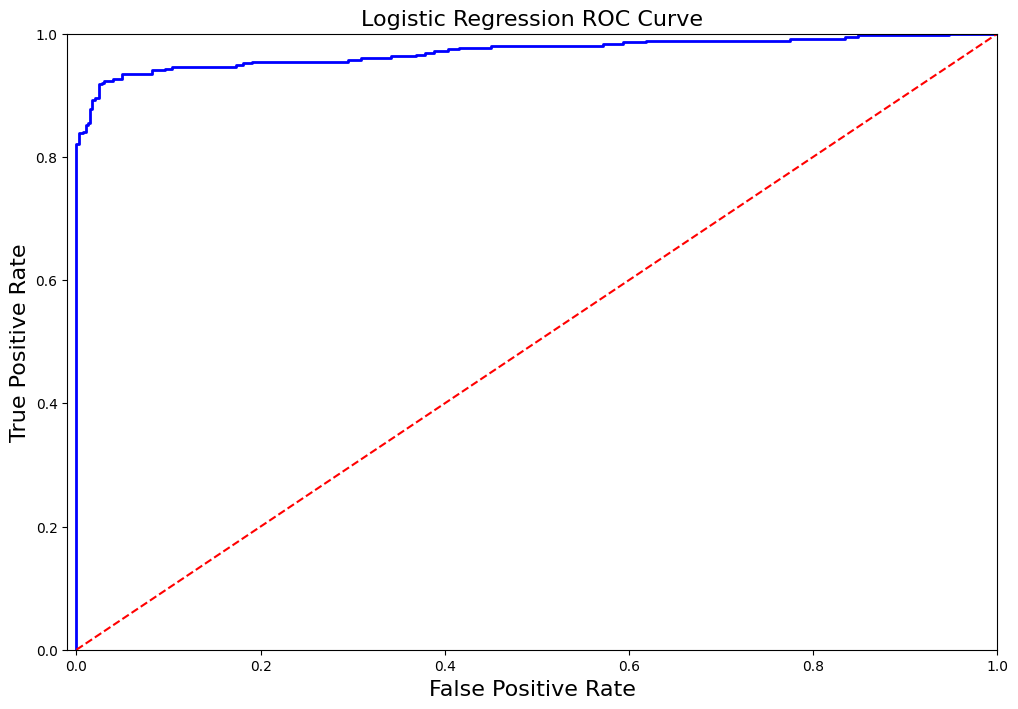

In [ ]:
def logistic_roc_curve(log_fpr, log_tpr):
    plt.figure(figsize=(12,8))
    plt.title('Logistic Regression ROC Curve', fontsize=16)
    plt.plot(log_fpr, log_tpr, 'b-', linewidth=2)
    plt.plot([0, 1], [0, 1], 'r--')
    plt.xlabel('False Positive Rate', fontsize=16)
    plt.ylabel('True Positive Rate', fontsize=16)
    plt.axis([-0.01,1,0,1])


logistic_roc_curve(log_fpr, log_tpr)
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, threshold = precision_recall_curve(y_train, log_reg_pred)

In [ ]:
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score
y_pred = log_reg.predict(X_train)

# Overfitting Case
print('---' * 45)
print('Overfitting: \n')
print('Recall Score: {:.2f}'.format(recall_score(y_train, y_pred)))
print('Precision Score: {:.2f}'.format(precision_score(y_train, y_pred)))
print('F1 Score: {:.2f}'.format(f1_score(y_train, y_pred)))
print('Accuracy Score: {:.2f}'.format(accuracy_score(y_train, y_pred)))
print('---' * 45)

# How it should look like
print('---' * 45)
print('How it should be:\n')
print("Accuracy Score: {:.2f}".format(np.mean(undersample_accuracy)))
print("Precision Score: {:.2f}".format(np.mean(undersample_precision)))
print("Recall Score: {:.2f}".format(np.mean(undersample_recall)))
print("F1 Score: {:.2f}".format(np.mean(undersample_f1)))
print('---' * 45)

---------------------------------------------------------------------------------------------------------------------------------------
Overfitting: 

Recall Score: 0.97
Precision Score: 0.61
F1 Score: 0.75
Accuracy Score: 0.70
---------------------------------------------------------------------------------------------------------------------------------------
---------------------------------------------------------------------------------------------------------------------------------------
How it should be:

Accuracy Score: 0.49
Precision Score: 0.00
Recall Score: 0.47
F1 Score: 0.00
---------------------------------------------------------------------------------------------------------------------------------------


In [ ]:
undersample_y_score = log_reg.decision_function(original_Xtest)

In [ ]:
from sklearn.metrics import average_precision_score

undersample_average_precision = average_precision_score(original_ytest, undersample_y_score)

print('Average precision-recall score: {0:0.2f}'.format(
      undersample_average_precision))

Average precision-recall score: 0.11


Text(0.5, 1.0, 'UnderSampling Precision-Recall curve: \n Average Precision-Recall Score =0.11')

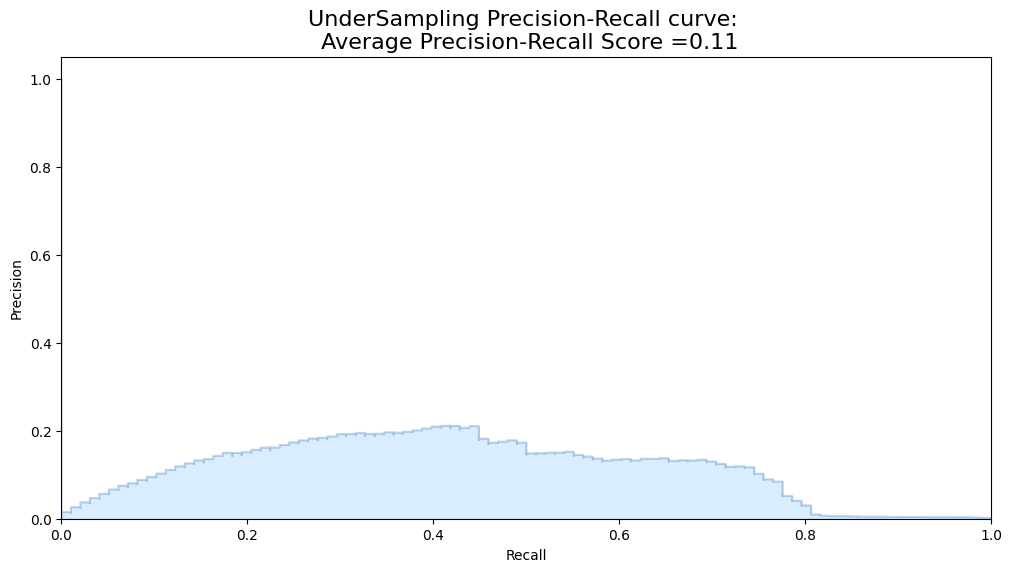

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12,6))

precision, recall, _ = precision_recall_curve(original_ytest, undersample_y_score)

plt.step(recall, precision, color='#004a93', alpha=0.2,
         where='post')
plt.fill_between(recall, precision, step='post', alpha=0.2,
                 color='#48a6ff')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('UnderSampling Precision-Recall curve: \n Average Precision-Recall Score ={0:0.2f}'.format(
          undersample_average_precision), fontsize=16)

<h2> SMOTE Oversampling Technique </h2>
<a id="smote"></a>

SMOTE (Synthetic Minority Oversampling Technique) is used to handle class imbalance by generating synthetic samples for the minority class instead of removing records from the majority class.

  

<h3> Understanding SMOTE </h3>

<ul>
<li> <b>Balancing the Dataset:</b> SMOTE creates additional synthetic fraud samples to achieve a more balanced class distribution. </li>

<li> <b>Synthetic Sample Generation:</b> New data points are generated based on the nearest neighbors of minority class samples. </li>

<li> <b>Improved Information Retention:</b> Since no majority class records are removed, more transaction information is preserved compared to undersampling techniques. </li>

<li> <b>Training Cost:</b> Oversampling increases the dataset size, which may require more training time and computational resources. </li>
</ul>


<h3> Correct Approach </h3>

<ul>
<li> Cross-validation should be performed first. </li>

<li> SMOTE must be applied only on the training folds during each validation cycle. </li>

<li> The validation data should remain untouched to ensure fair evaluation. </li>

<li> This process prevents data leakage and produces more realistic model performance results. </li>
</ul>


In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, RandomizedSearchCV


print('Length of X (train): {} | Length of y (train): {}'.format(len(original_Xtrain), len(original_ytrain)))
print('Length of X (test): {} | Length of y (test): {}'.format(len(original_Xtest), len(original_ytest)))

# List to append the score and then find the average
accuracy_lst = []
precision_lst = []
recall_lst = []
f1_lst = []
auc_lst = []

# Classifier with optimal parameters
# log_reg_sm = grid_log_reg.best_estimator_
log_reg_sm = LogisticRegression()




rand_log_reg = RandomizedSearchCV(LogisticRegression(), log_reg_params, n_iter=4)


# Implementing SMOTE Technique
# Cross Validating the right way
# Parameters
log_reg_params = {"penalty": ['l1', 'l2'], 'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}
for train, test in sss.split(original_Xtrain, original_ytrain):
    pipeline = imbalanced_make_pipeline(SMOTE(sampling_strategy='minority'), rand_log_reg) # SMOTE happens during Cross Validation not before..
    model = pipeline.fit(original_Xtrain[train], original_ytrain[train])
    best_est = rand_log_reg.best_estimator_
    prediction = best_est.predict(original_Xtrain[test])

    accuracy_lst.append(pipeline.score(original_Xtrain[test], original_ytrain[test]))
    precision_lst.append(precision_score(original_ytrain[test], prediction))
    recall_lst.append(recall_score(original_ytrain[test], prediction))
    f1_lst.append(f1_score(original_ytrain[test], prediction))
    auc_lst.append(roc_auc_score(original_ytrain[test], prediction))

print('---' * 45)
print('')
print("accuracy: {}".format(np.mean(accuracy_lst)))
print("precision: {}".format(np.mean(precision_lst)))
print("recall: {}".format(np.mean(recall_lst)))
print("f1: {}".format(np.mean(f1_lst)))
print('---' * 45)

Length of X (train): 227846 | Length of y (train): 227846
Length of X (test): 56961 | Length of y (test): 56961
---------------------------------------------------------------------------------------------------------------------------------------

accuracy: 0.9411977918512751
precision: 0.059311703420565486
recall: 0.9137293086660175
f1: 0.10965802932286928
---------------------------------------------------------------------------------------------------------------------------------------


In [ ]:
labels = ['No Fraud', 'Fraud']
smote_prediction = best_est.predict(original_Xtest)
print(classification_report(original_ytest, smote_prediction, target_names=labels))

              precision    recall  f1-score   support

    No Fraud       1.00      0.99      0.99     56863
       Fraud       0.10      0.86      0.18        98

    accuracy                           0.99     56961
   macro avg       0.55      0.92      0.58     56961
weighted avg       1.00      0.99      0.99     56961



In [ ]:
y_score = best_est.decision_function(original_Xtest)

In [ ]:
average_precision = average_precision_score(original_ytest, y_score)

print('Average precision-recall score: {0:0.2f}'.format(
      average_precision))

Average precision-recall score: 0.70


Text(0.5, 1.0, 'OverSampling Precision-Recall curve: \n Average Precision-Recall Score =0.70')

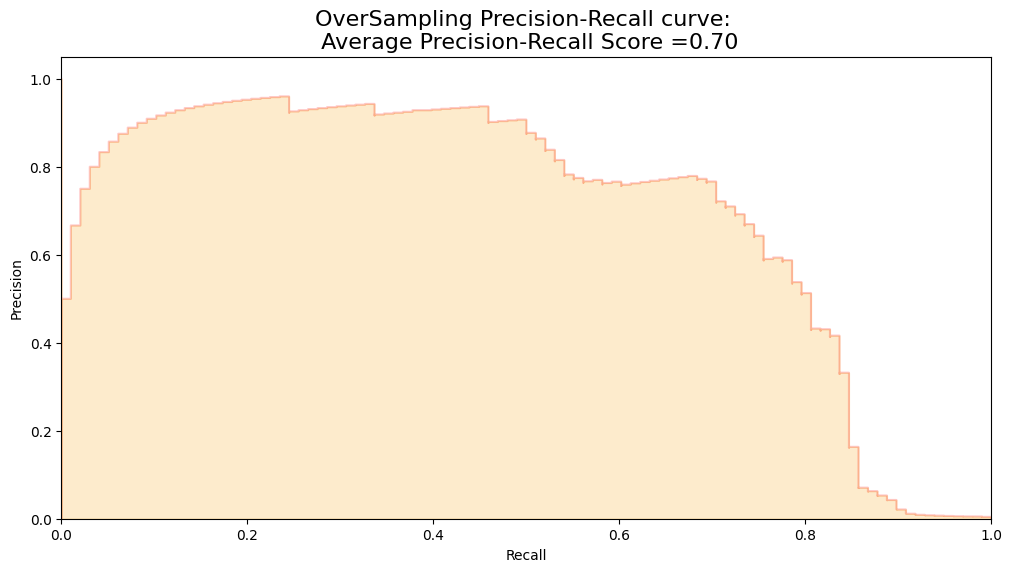

In [ ]:
fig = plt.figure(figsize=(12,6))

precision, recall, _ = precision_recall_curve(original_ytest, y_score)

plt.step(recall, precision, color='r', alpha=0.2,
         where='post')
plt.fill_between(recall, precision, step='post', alpha=0.2,
                 color='#F59B00')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('OverSampling Precision-Recall curve: \n Average Precision-Recall Score ={0:0.2f}'.format(
          average_precision), fontsize=16)

In [ ]:
# SMOTE Technique (OverSampling) After splitting and Cross Validating
sm = SMOTE(sampling_strategy='minority', random_state=42)
# Xsm_train, ysm_train = sm.fit_resample(X_train, y_train)


# This will be the data were we are going to
Xsm_train, ysm_train = sm.fit_resample(original_Xtrain, original_ytrain)

In [ ]:
# We Improve the score by 2% points approximately
# Implement GridSearchCV and the other models.

# Logistic Regression
t0 = time.time()
log_reg_sm = grid_log_reg.best_estimator_
log_reg_sm.fit(Xsm_train, ysm_train)
t1 = time.time()
print("Fitting oversample data took :{} sec".format(t1 - t0))

Fitting oversample data took :8.805846452713013 sec


<h2> Logistic Regression Testing </h2>
<a id="testing_logistic"></a>

In this section, the Logistic Regression model is evaluated using the testing dataset. The performance of the model is analyzed using a confusion matrix, which helps measure how accurately fraud and non-fraud transactions are classified.

<h3> Confusion Matrix </h3>

The confusion matrix is a performance evaluation tool used to compare actual class labels with predicted labels generated by the model.

<ul>
<li><b>True Negative (TN):</b> Non-fraud transactions correctly classified as legitimate transactions. </li>

<li><b>False Negative (FN):</b> Fraud transactions incorrectly classified as non-fraud transactions. </li>

<li><b>False Positive (FP):</b> Non-fraud transactions incorrectly classified as fraud transactions. </li>

<li><b>True Positive (TP):</b> Fraud transactions correctly identified by the model. </li>
</ul>

<h3> Model Evaluation </h3>

The confusion matrix provides a detailed understanding of how well the model detects fraudulent activities while minimizing incorrect predictions.

<h3> Summary: </h3>

<ul>
<li> The Logistic Regression model is evaluated using the balanced undersampled dataset. </li>

<li> The testing process helps analyze how effectively the classifier distinguishes fraud and non-fraud transactions. </li>

<li> Logistic Regression and Support Vector Machine (SVM) show the strongest overall classification performance. </li>

<li> The confusion matrix highlights both correct predictions and classification errors made by the model. </li>

<li> Performance evaluation helps identify areas where the fraud detection system can be further improved. </li>
</ul>

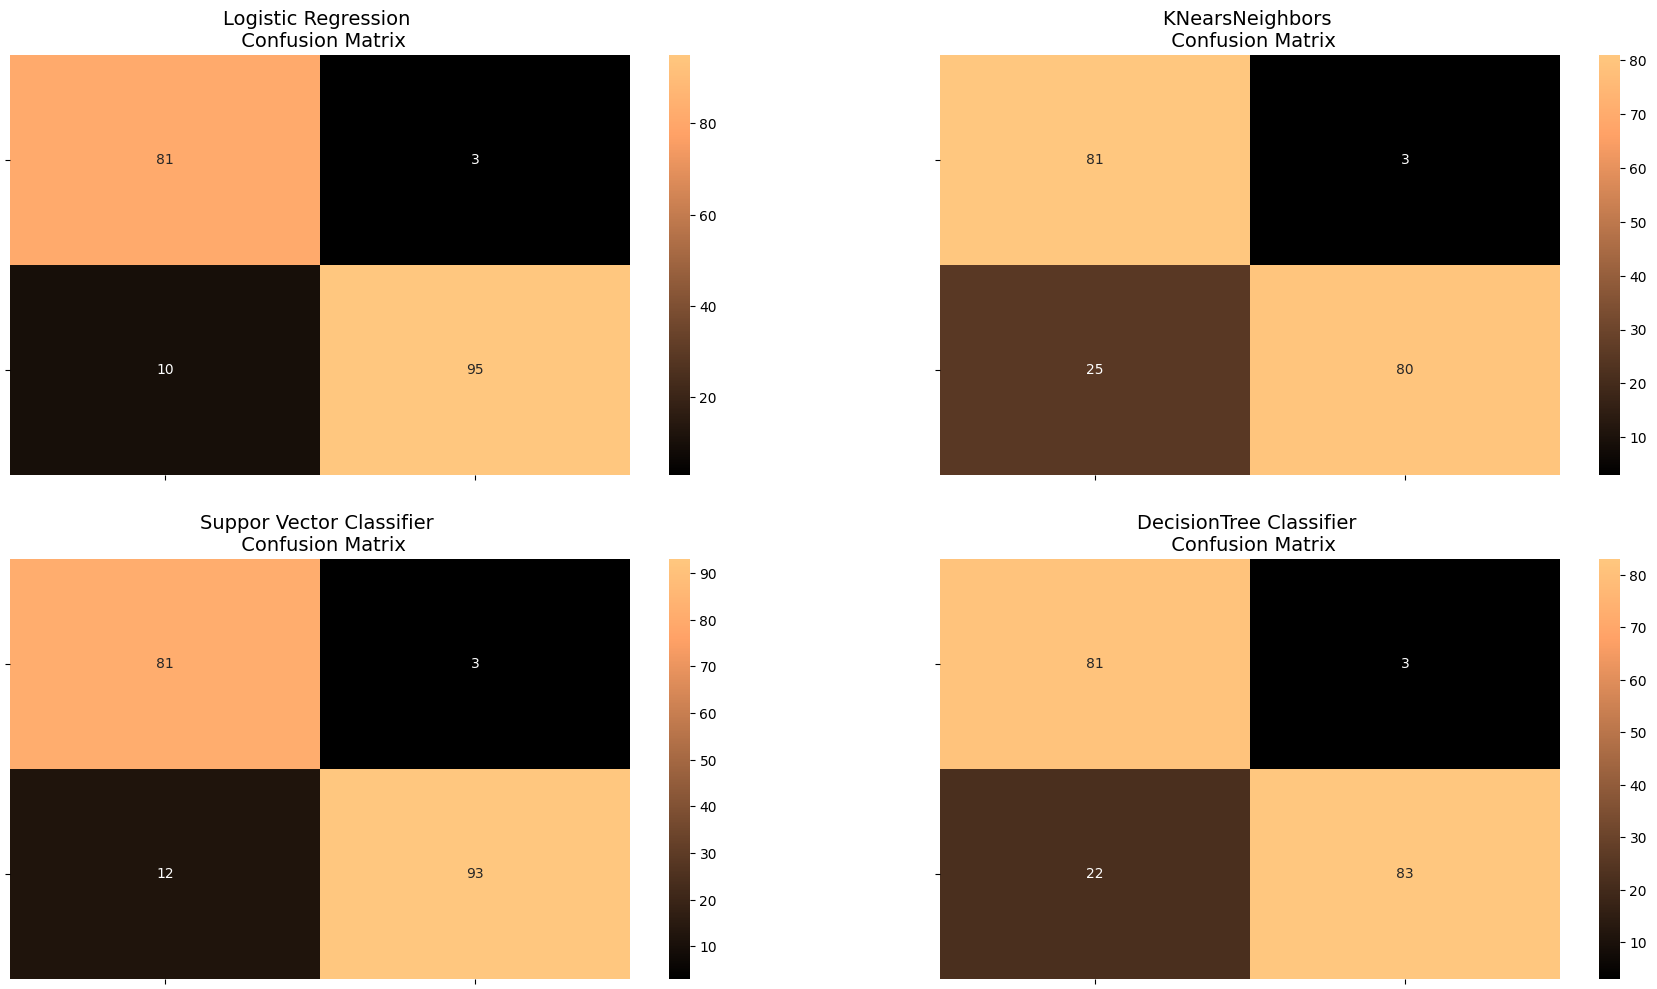

In [ ]:
from sklearn.metrics import confusion_matrix

# Logistic Regression fitted using SMOTE technique
y_pred_log_reg = log_reg_sm.predict(X_test)

# Other models fitted with UnderSampling
y_pred_knear = knears_neighbors.predict(X_test)
y_pred_svc = svc.predict(X_test)
y_pred_tree = tree_clf.predict(X_test)


log_reg_cf = confusion_matrix(y_test, y_pred_log_reg)
kneighbors_cf = confusion_matrix(y_test, y_pred_knear)
svc_cf = confusion_matrix(y_test, y_pred_svc)
tree_cf = confusion_matrix(y_test, y_pred_tree)

fig, ax = plt.subplots(2, 2,figsize=(22,12))


sns.heatmap(log_reg_cf, ax=ax[0][0], annot=True, cmap=plt.cm.copper)
ax[0, 0].set_title("Logistic Regression \n Confusion Matrix", fontsize=14)
ax[0, 0].set_xticklabels(['', ''], fontsize=14, rotation=90)
ax[0, 0].set_yticklabels(['', ''], fontsize=14, rotation=360)

sns.heatmap(kneighbors_cf, ax=ax[0][1], annot=True, cmap=plt.cm.copper)
ax[0][1].set_title("KNearsNeighbors \n Confusion Matrix", fontsize=14)
ax[0][1].set_xticklabels(['', ''], fontsize=14, rotation=90)
ax[0][1].set_yticklabels(['', ''], fontsize=14, rotation=360)

sns.heatmap(svc_cf, ax=ax[1][0], annot=True, cmap=plt.cm.copper)
ax[1][0].set_title("Suppor Vector Classifier \n Confusion Matrix", fontsize=14)
ax[1][0].set_xticklabels(['', ''], fontsize=14, rotation=90)
ax[1][0].set_yticklabels(['', ''], fontsize=14, rotation=360)

sns.heatmap(tree_cf, ax=ax[1][1], annot=True, cmap=plt.cm.copper)
ax[1][1].set_title("DecisionTree Classifier \n Confusion Matrix", fontsize=14)
ax[1][1].set_xticklabels(['', ''], fontsize=14, rotation=90)
ax[1][1].set_yticklabels(['', ''], fontsize=14, rotation=360)


plt.show()

In [ ]:
from sklearn.metrics import classification_report


print('Logistic Regression:')
print(classification_report(y_test, y_pred_log_reg))

print('KNears Neighbors:')
print(classification_report(y_test, y_pred_knear))

print('Support Vector Classifier:')
print(classification_report(y_test, y_pred_svc))

print('Support Vector Classifier:')
print(classification_report(y_test, y_pred_tree))

Logistic Regression:
              precision    recall  f1-score   support

           0       0.89      0.96      0.93        84
           1       0.97      0.90      0.94       105

    accuracy                           0.93       189
   macro avg       0.93      0.93      0.93       189
weighted avg       0.93      0.93      0.93       189

KNears Neighbors:
              precision    recall  f1-score   support

           0       0.76      0.96      0.85        84
           1       0.96      0.76      0.85       105

    accuracy                           0.85       189
   macro avg       0.86      0.86      0.85       189
weighted avg       0.88      0.85      0.85       189

Support Vector Classifier:
              precision    recall  f1-score   support

           0       0.87      0.96      0.92        84
           1       0.97      0.89      0.93       105

    accuracy                           0.92       189
   macro avg       0.92      0.93      0.92       189
weighted

In [ ]:
# Final Score in the test set of logistic regression
from sklearn.metrics import accuracy_score

# Logistic Regression with Under-Sampling
y_pred = log_reg.predict(X_test)
undersample_score = accuracy_score(y_test, y_pred)



# Logistic Regression with SMOTE Technique (Better accuracy with SMOTE t)
y_pred_sm = best_est.predict(original_Xtest)
oversample_score = accuracy_score(original_ytest, y_pred_sm)


d = {'Technique': ['Random UnderSampling', 'Oversampling (SMOTE)'], 'Score': [undersample_score, oversample_score]}
final_df = pd.DataFrame(data=d)

# Move column
score = final_df['Score']
final_df.drop('Score', axis=1, inplace=True)
final_df.insert(1, 'Score', score)

# Note how high is accuracy score it can be misleading!
final_df

,Technique,Score
0,Random UnderSampling,0.931217
1,Oversampling (SMOTE),0.986184


<h2> Neural Network Testing: UnderSampling vs SMOTE </h2>
<a id="neural_networks"></a>

In this section, a simple Neural Network model is used to compare the performance of Random UnderSampling and SMOTE Oversampling. The purpose is to check which balanced dataset helps the model classify fraud and non-fraud transactions more effectively.

The neural network is trained using both sampled datasets, but the final evaluation is performed on the original testing data.

<h3> Main Objective </h3>

The main goal is to understand how the Neural Network performs with both undersampled and oversampled training data.

The model should not only detect fraud transactions correctly but also classify normal transactions accurately. This is important because incorrectly labeling a normal transaction as fraud may create problems for genuine users.

<h3> Confusion Matrix Review </h3>

The confusion matrix helps evaluate the prediction results of the Neural Network.

<ul>
<li><b>Upper Left:</b> Non-fraud transactions correctly classified as non-fraud. </li>

<li><b>Upper Right:</b> Non-fraud transactions incorrectly classified as fraud. </li>

<li><b>Lower Left:</b> Fraud transactions incorrectly classified as non-fraud. </li>

<li><b>Lower Right:</b> Fraud transactions correctly classified as fraud. </li>
</ul>

<h3> Summary: </h3>

<ul>
<li><b>Dataset Comparison:</b> The Neural Network is trained using both the <b>Random UnderSampled dataset</b> and the <b>SMOTE Oversampled dataset</b>. </li>

<li><b>Testing Data:</b> Final predictions are made on the original testing dataset to measure real performance. </li>

<li><b>Model Structure:</b> The Neural Network contains an input layer based on the number of features, one hidden layer with 32 neurons, and one output layer for binary classification. </li>

<li><b>Activation Function:</b> ReLU is used in the hidden layer to learn non-linear patterns from the transaction data. </li>

<li><b>Optimizer:</b> Adam optimizer is used with a learning rate of 0.001 for efficient model training. </li>

<li><b>Output:</b> The model predicts whether a transaction is fraud or non-fraud based on the highest predicted probability. </li>

<li><b>Evaluation:</b> Confusion matrix, precision, recall, and F1-score are used to compare both approaches. </li>
</ul>

In [ ]:
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

n_inputs = X_train.shape[1]

undersample_model = Sequential([
    Dense(n_inputs, input_shape=(n_inputs, ), activation='relu'),
    Dense(32, activation='relu'),
    Dense(2, activation='softmax')
])

In [ ]:
undersample_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,988 (7.77 KB)

 Trainable params: 1,988 (7.77 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
undersample_model.compile(Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
undersample_model.fit(X_train, y_train, validation_split=0.2, batch_size=25, epochs=20, shuffle=True, verbose=2)

Epoch 1/20
25/25 - 2s - 98ms/step - accuracy: 0.7053 - loss: 0.4649 - val_accuracy: 0.8882 - val_loss: 0.3203
Epoch 2/20
25/25 - 0s - 10ms/step - accuracy: 0.9172 - loss: 0.2931 - val_accuracy: 0.9211 - val_loss: 0.2482
Epoch 3/20
25/25 - 0s - 12ms/step - accuracy: 0.9338 - loss: 0.2267 - val_accuracy: 0.9276 - val_loss: 0.2175
Epoch 4/20
25/25 - 0s - 14ms/step - accuracy: 0.9387 - loss: 0.1887 - val_accuracy: 0.9276 - val_loss: 0.2026
Epoch 5/20
25/25 - 0s - 12ms/step - accuracy: 0.9487 - loss: 0.1635 - val_accuracy: 0.9211 - val_loss: 0.1944
Epoch 6/20
25/25 - 0s - 13ms/step - accuracy: 0.9570 - loss: 0.1438 - val_accuracy: 0.9211 - val_loss: 0.1904
Epoch 7/20
25/25 - 1s - 22ms/step - accuracy: 0.9619 - loss: 0.1319 - val_accuracy: 0.9211 - val_loss: 0.1880
Epoch 8/20
25/25 - 0s - 17ms/step - accuracy: 0.9619 - loss: 0.1206 - val_accuracy: 0.9211 - val_loss: 0.1876
Epoch 9/20
25/25 - 1s - 20ms/step - accuracy: 0.9636 - loss: 0.1127 - val_accuracy: 0.9211 - val_loss: 0.1876
Epoch 10/2

In [ ]:
undersample_predictions = undersample_model.predict(original_Xtest, batch_size=200, verbose=0)

In [ ]:
undersample_fraud_predictions = np.argmax(undersample_model.predict(original_Xtest, batch_size=200, verbose=0), axis=1)

In [ ]:
import itertools

# Create a confusion matrix
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=14)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

Confusion matrix, without normalization
[[55728  1135]
 [    9    89]]
Confusion matrix, without normalization
[[56863     0]
 [    0    98]]


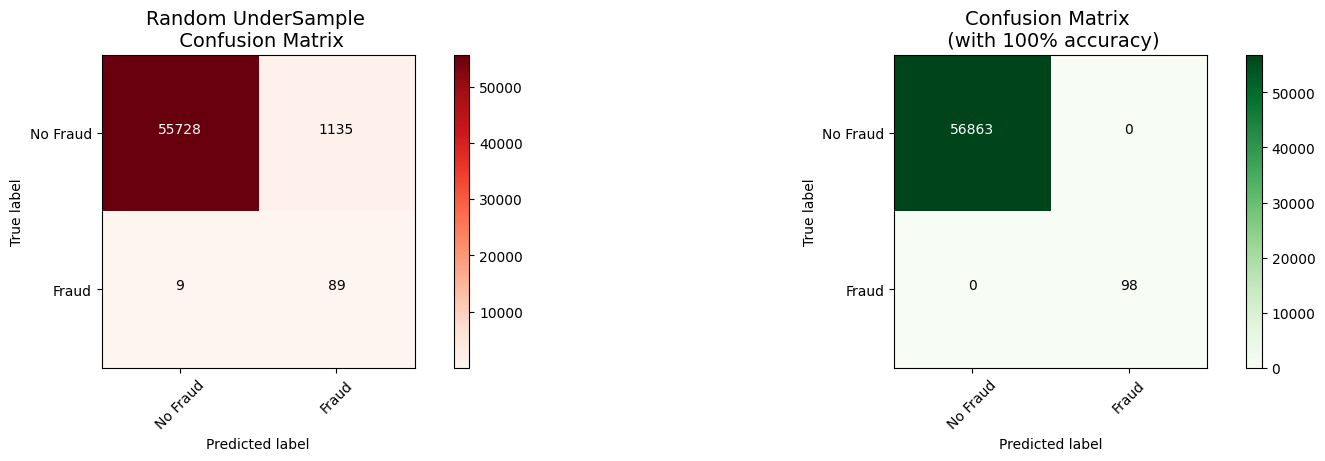

In [ ]:
undersample_cm = confusion_matrix(original_ytest, undersample_fraud_predictions)
actual_cm = confusion_matrix(original_ytest, original_ytest)
labels = ['No Fraud', 'Fraud']

fig = plt.figure(figsize=(16,8))

fig.add_subplot(221)
plot_confusion_matrix(undersample_cm, labels, title="Random UnderSample \n Confusion Matrix", cmap=plt.cm.Reds)

fig.add_subplot(222)
plot_confusion_matrix(actual_cm, labels, title="Confusion Matrix \n (with 100% accuracy)", cmap=plt.cm.Greens)

### Keras || OverSampling (SMOTE):


In [ ]:
n_inputs = Xsm_train.shape[1]

oversample_model = Sequential([
    Dense(n_inputs, input_shape=(n_inputs, ), activation='relu'),
    Dense(32, activation='relu'),
    Dense(2, activation='softmax')
])

In [ ]:
oversample_model.compile(Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
oversample_model.fit(Xsm_train, ysm_train, validation_split=0.2, batch_size=300, epochs=20, shuffle=True, verbose=2)

Epoch 1/20
1214/1214 - 8s - 7ms/step - accuracy: 0.9777 - loss: 0.0670 - val_accuracy: 0.9964 - val_loss: 0.0177
Epoch 2/20
1214/1214 - 4s - 4ms/step - accuracy: 0.9968 - loss: 0.0138 - val_accuracy: 1.0000 - val_loss: 0.0069
Epoch 3/20
1214/1214 - 5s - 4ms/step - accuracy: 0.9983 - loss: 0.0080 - val_accuracy: 1.0000 - val_loss: 0.0037
Epoch 4/20
1214/1214 - 6s - 5ms/step - accuracy: 0.9989 - loss: 0.0055 - val_accuracy: 1.0000 - val_loss: 0.0028
Epoch 5/20
1214/1214 - 7s - 6ms/step - accuracy: 0.9991 - loss: 0.0042 - val_accuracy: 1.0000 - val_loss: 0.0027
Epoch 6/20
1214/1214 - 4s - 3ms/step - accuracy: 0.9992 - loss: 0.0035 - val_accuracy: 0.9999 - val_loss: 0.0034
Epoch 7/20
1214/1214 - 3s - 2ms/step - accuracy: 0.9994 - loss: 0.0030 - val_accuracy: 1.0000 - val_loss: 8.4922e-04
Epoch 8/20
1214/1214 - 4s - 4ms/step - accuracy: 0.9995 - loss: 0.0025 - val_accuracy: 1.0000 - val_loss: 0.0041
Epoch 9/20
1214/1214 - 5s - 4ms/step - accuracy: 0.9995 - loss: 0.0022 - val_accuracy: 1.000

In [ ]:
oversample_predictions = oversample_model.predict(original_Xtest, batch_size=200, verbose=0)

In [ ]:
oversample_fraud_predictions = np.argmax(oversample_model.predict(original_Xtest, batch_size=200, verbose=0), axis=1)

Confusion matrix, without normalization
[[56855     8]
 [   29    69]]
Confusion matrix, without normalization
[[56863     0]
 [    0    98]]


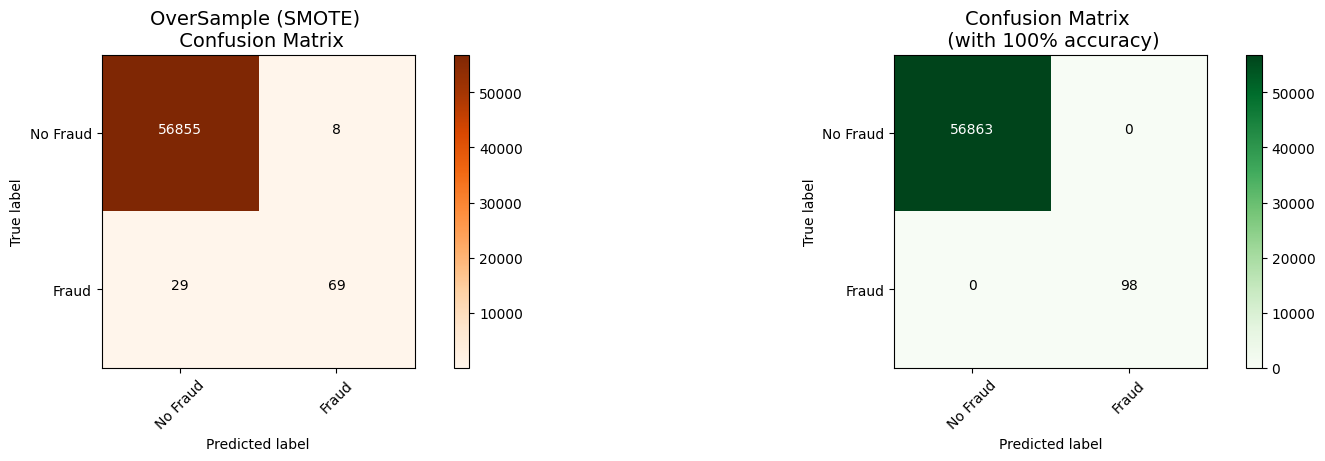

In [ ]:
oversample_smote = confusion_matrix(original_ytest, oversample_fraud_predictions)
actual_cm = confusion_matrix(original_ytest, original_ytest)
labels = ['No Fraud', 'Fraud']

fig = plt.figure(figsize=(16,8))

fig.add_subplot(221)
plot_confusion_matrix(oversample_smote, labels, title="OverSample (SMOTE) \n Confusion Matrix", cmap=plt.cm.Oranges)

fig.add_subplot(222)
plot_confusion_matrix(actual_cm, labels, title="Confusion Matrix \n (with 100% accuracy)", cmap=plt.cm.Greens)

<h2> Conclusion </h2>

In this project, different Machine Learning and Deep Learning techniques were applied to detect fraudulent financial transactions using an imbalanced dataset. Both Random UnderSampling and SMOTE Oversampling methods were used to improve class balance and help the models learn fraud patterns more effectively.

The experimental results show that balancing techniques can significantly improve fraud detection performance. Logistic Regression and Neural Network models performed well in separating fraud and non-fraud transactions, especially after preprocessing and feature analysis.

Although SMOTE preserved more information by generating synthetic fraud samples, the undersampled dataset sometimes produced better fraud detection results. One possible reason is that outlier removal was only applied to the undersampled dataset and not to the oversampled dataset.

At the same time, the undersampling approach also introduced certain limitations. In some cases, legitimate transactions were incorrectly classified as fraud transactions. In real-world financial systems, this may lead to customer dissatisfaction, transaction interruptions, and reduced trust in banking services.

Therefore, fraud detection systems should maintain a balance between:
<ul>
<li> Correctly identifying fraud transactions </li>
<li> Minimizing false fraud alerts for genuine users </li>
</ul>

<h3> Final Observations: </h3>

<ul>
<li> Class imbalance handling is essential for fraud detection problems. </li>

<li> Random UnderSampling improves fraud learning but may cause information loss. </li>

<li> SMOTE Oversampling preserves more data and improves dataset balance. </li>

<li> Logistic Regression showed stable and reliable performance across different experiments. </li>

<li> Neural Networks were able to learn complex transaction patterns and produce competitive results. </li>

<li> Outlier removal and preprocessing techniques positively affected model performance. </li>

<li> Model predictions may slightly vary because of random data shuffling during training. </li>
</ul>

<h3> Future Improvements: </h3>

<ul>
<li> Apply outlier removal techniques on the SMOTE oversampled dataset. </li>

<li> Experiment with advanced Deep Learning architectures for better fraud detection. </li>

<li> Perform hyperparameter optimization to improve model generalization. </li>

<li> Explore ensemble learning techniques to increase prediction stability and accuracy. </li>
</ul>